# Mapeamento dos dois artigos de reviews de Física de Neutrinos


**Iniciação científica:** *Dirac or Majorana Neutrinos — Phenomenological Consequences*


**Autor:** João Henrique C. B. Miranda, Bacharelado em Física, Universidade Estadual de Londrina (UEL)

**Orientador**: Prof. Dr. Pietro Chimenti

---
**Descrição**: Este Notebook são os resultados da tarefa proposta pelo orientador: *pegar **todas** as referências dos dois artigos de review abaixo, levantar a contagem de citações de cada um num banco de citações e mapear a relação entre o ano e impacto dos trabalhos, para então selecionar os mais citados que dialogam com o projeto da IC.*

**Artigos**: 

[ 1 ] AGOSTINI, M.; BENATO, G.; DETWILER, J. A.; MENÉNDEZ, J.; VISSANI, F. Toward the discovery of matter creation with neutrinoless ββ decay. Reviews of Modern Physics, [S. l.], v. 95, n. 2, p. 025002, 2023.

[ 2 ] GONZALEZ-GARCIA, M. C.; WENDELL, R. Neutrino Masses, Mixing, and Oscillations. In: PARTICLE DATA GROUP. Review of Particle Physics. [S. l.]: Particle Data Group, 2026. cap. 14. Revisado em março de 2026.

**Base de citações:** [INSPIRE-HEP](https://inspirehep.net) · Coleta feita entre 6 e 12 de setembro de 2026

--- 
Como foi feita a coleta dos dados: 

| Etapa | O que foi feito |
|---|---|
| Extração | Parsing do texto das duas bibliografias em PDF, com reconstrução das entradas quebradas por coluna e página |
| Deduplicação | Chave por arXiv ID → DOI → título; depois, deduplicação definitiva pelo `inspire_id` devolvido pela API |
| Identificação | Cadeia `arxiv:` → `doi:` → `j+<revista>,<vol>,<pág>` → `t+<título>` → `a+<autor>+and+date+<ano>` |
| Validação | Cada registro exigiu **duas âncoras**: ano compatível **e** título ou coordenada de journal batendo com o texto da bibliografia |
| Resultados | Uma linha por bloco reconferida manualmente, fora do processo automático — 47 conferências, todas exatas |

O trabalho foi dividido em 51 blocos de 20 buscas.

|Cobertura | números | 
|---|---|
| Referências brutas extraídas | 996 |
| **Referências únicas** | **970** |
| Com citação recuperada | **888** (91,5%) |
| Sem registro no INSPIRE | 62 (6,4%) |
| Duplicatas entre as duas reviews | 20 |

**Nota**: As 62 sem registro no inspire são teses de doutorado, atas de workshop, apresentações em conferência, bancos de dados nucleares (ENSDF, XUNDL) e artigos em revistas de química e engenharia (categorias que o INSPIRE-HEP não indexa). Onze casos foram reconferidos à mão, um deles duas vezes: o artigo de Walz *et al.* na **Nature** 526, 406 (2015), sobre decaimento duplo gama, realmente não tem registro na base.

**Nota**[!]: O INSPIRE devolve `earliest_date`, que é a data do **preprint**, não a da publicação. Para um trabalho dos anos 2010 a diferença é de meses; para alguns é de dois anos. **Os gráficos usam `earliest_date`** (é a data que mede há quanto tempo o trabalho está disponível para ser citado); **as tabelas de referência usam o ano de publicação no periódico**, como manda a ABNT. Quando os dois divergem, a tabela registra os dois.

In [9]:
import csv, collections, statistics, textwrap
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MultipleLocator
from IPython.display import Markdown, display

AZUL, LARANJA, VERDE, CINZA = '#0072B2', '#D55E00', '#009E73', '#6B6B6B'
TINTA, TINTA2 = '#1A1A1A', '#5A5A5A'
ESTILO = {
    'AGOSTINI':                 dict(cor=AZUL,    marcador='o', rotulo='Agostini et al. (RMP, 0νββ)'),
    'GONZALEZ-GARCIA':          dict(cor=LARANJA, marcador='^', rotulo='Gonzalez-Garcia et al. (PDG, oscilações)'),
    'AGOSTINI;GONZALEZ-GARCIA': dict(cor=VERDE,   marcador='s', rotulo='Citado pelas duas reviews'),
}
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
    'axes.edgecolor': '#BFBFBF', 'axes.linewidth': .8, 'axes.labelcolor': TINTA,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': TINTA2, 'ytick.color': TINTA2,
    'grid.color': '#E2E2E2', 'grid.linewidth': .7, 'legend.frameon': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
ANO_REF = 2026   # ano de referencia para calcular idade e taxa de citacao

def carregar(caminho='dados/citacoes/dados_citacoes.csv', campo='citacoes'):
    '''descarta duplicatas por inspire_id e o que nao tem citacao.'''
    fora = []
    for r in csv.DictReader(open(caminho, encoding='utf-8')):
        ano, cit = (r['ano_inspire'] or r['ano_ref']).strip(), (r[campo] or '').strip()
        if not ano.isdigit() or not cit.isdigit():   continue
        if (r.get('duplicata_de') or '').strip():    continue   # ja contabilizado em outro uid
        r['ano'], r['cit'] = int(ano), int(cit)
        r['idade'] = max(ANO_REF - r['ano'], 1)
        r['taxa']  = r['cit'] / r['idade']
        fora.append(r)
    return fora

D = carregar()
print(f'{len(D)} referências na análise')
print(f"mediana {statistics.median(c['cit'] for c in D):.0f} · "
      f"média {statistics.mean(c['cit'] for c in D):.0f} · "
      f"máximo {max(c['cit'] for c in D)}")
print('por fonte:', dict(collections.Counter(r['fontes'] for r in D)))

888 referências na análise
mediana 124 · média 457 · máximo 23108
por fonte: {'AGOSTINI': 650, 'GONZALEZ-GARCIA': 222, 'AGOSTINI;GONZALEZ-GARCIA': 16}


**Nota**: A mediana de 124 citações em relação a uma média de 457 diz que a distribuição é fortemente assimétrica. Meia dúzia de trabalhos concentra uma fração enorme das citações, e a maior parte das referências vive na casa das dezenas. Qualquer leitura por média ficaria horrível de analisar; todos os gráficos que seguem eu irei utlizar escala logarítmica no eixo das citações.

---
## Figura 1 — Ano × impacto de citação

**Tarefa**: quais são os artigos mais novos e suas citações, e os mais velhos e suas citações?

**Objetivo**: verificar se a idade de um trabalho influencia o número de citações recebidas, e
identificar os mais citados entre os extremos, os mais recentes e os mais antigos dos dados.

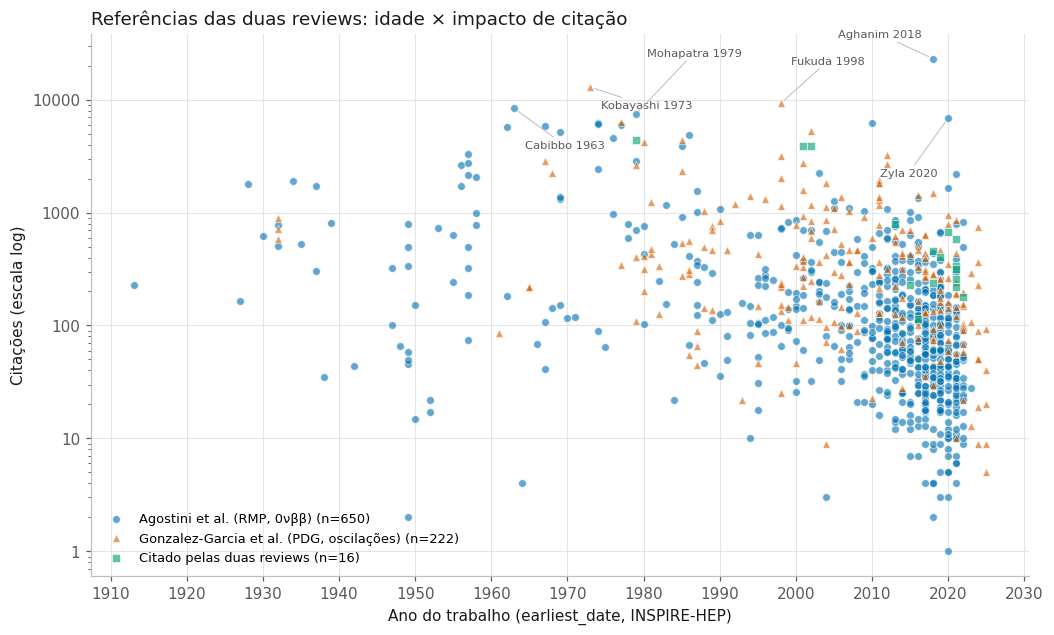

In [10]:
def rotular(ax, pontos, chave, n=6):
    '''Rotula apenas os n extremos, com linha de chamada e deslocamento alternado.'''
    top = sorted(pontos, key=lambda r: -chave(r))[:n]
    xs = [r['ano'] for r in top]; xmin, xmax = min(xs), max(xs)
    for i, r in enumerate(top):
        nome = (r['primeiro_autor'] or r['autor_ref']).split(',')[0][:16]
        borda = (xmax - r['ano']) < .12 * max(xmax - xmin, 1)
        dx, ha = (-7, 'right') if borda else (7, 'left')
        ax.annotate(f"{nome} {r['ano']}", (r['ano'], chave(r)), textcoords='offset points',
                    xytext=(dx, (14, -14, 26, -26, 38, -38)[i % 6]), ha=ha, fontsize=7.5,
                    color=TINTA2, zorder=5,
                    arrowprops=dict(arrowstyle='-', lw=.6, color='#B8B8B8', shrinkA=0, shrinkB=3))

fig, ax = plt.subplots(figsize=(11, 6.4))
ax.set_axisbelow(True); ax.grid(True, alpha=.9)
for chave, e in ESTILO.items():
    g = [r for r in D if r['fontes'] == chave]
    ax.scatter([r['ano'] for r in g], [r['cit'] for r in g], s=26, c=e['cor'],
               marker=e['marcador'], alpha=.62, linewidths=.6, edgecolors='white',
               label=f"{e['rotulo']} (n={len(g)})", zorder=3)
ax.set_yscale('log')
ax.set_xlabel('Ano do trabalho (earliest_date, INSPIRE-HEP)')
ax.set_ylabel('Citações (escala log)')
ax.set_title('Referências das duas reviews: idade × impacto de citação', loc='left', color=TINTA)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(ScalarFormatter())
rotular(ax, D, lambda r: r['cit'])
ax.legend(loc='lower left', fontsize=8.5)
plt.show()

**Descrição do gráfico:**

Cada ponto é uma referência dos dados. O eixo horizontal é o ano em que o trabalho apareceu
(`earliest_date` do INSPIRE-HEP, ou seja, a data do preprint); o eixo vertical é o número de
citações acumuladas até hoje, em **escala logarítmica**, necessária porque os valores vão de
poucas unidades a mais de 23 mil. Marcador e cor identificam qual review cita o trabalho: círculo
azul para a review do Agostini (0νββ), triângulo laranja para a do Gonzalez-Garcia (oscilações),
quadrado verde para os que aparecem nas duas. Os seis pontos mais citados são rotulados com o
primeiro autor e o ano.

**Peculiaridades do gráfico:**

Não existe correlação simples entre idade e citação. Se houvesse, os pontos formariam uma faixa
descendente da esquerda para a direita, trabalhos velhos com muitas citações, novos com poucas. O
que se vê é uma nuvem espalhada em três ordens de magnitude em qualquer fatia de tempo depois de
1960; em 1980 há trabalhos com 4.000 citações e trabalhos com 20.

O eixo vertical separa os que viraram infraestrutura conceitual da área
do resto. Os pontos no alto, entre 4.000 e 13.000 citações, são quase todos anteriores a 1990 e são
os artigos que fundaram os formalismos (Kobayashi–Maskawa, Cabibbo, Mohapatra–Senjanović,
Wolfenstein, Minkowski, Maki–Nakagawa–Sakata). Nenhum deles é sobre decaimento duplo beta; são sobre
mistura de sabores, massa e violação de simetrias, ou seja, exatamente a camada teórica de que o
0νββ depende.

Um ponto se isola no topo à direita: é o Planck 2018, com 23.108 citações, 2,5 vezes o segundo
colocado. Não é um trabalho de física de neutrinos; é o vínculo cosmológico que as duas reviews
usam como entrada externa.

A densidade da nuvem também cresce visivelmente depois de 2005, uma propriedade da bibliografia: reviews citam preferencialmente literatura recente.

---
## Figura 2 — Perfil temporal dos dados

**Tarefa**: quantas referências cada ano fornece às duas reviews?

**Objetivo**: medir o viés de recência da bibliografia; verificar se as reviews citam
predominantemente literatura recente ou se a distribuição é mais uniforme ao longo do tempo.

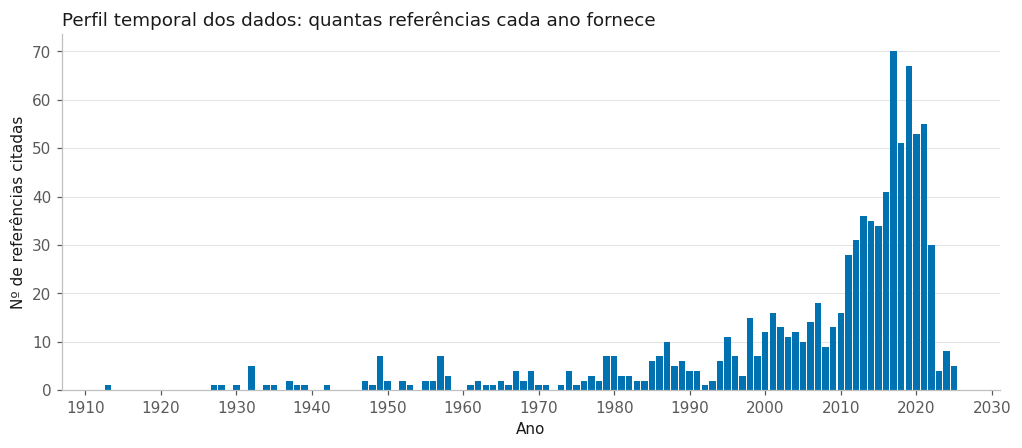

| Década | Referências | % dos dados |
|---|---|---|
| 1910s | 1 | 0.1% |
| 1920s | 2 | 0.2% |
| 1930s | 12 | 1.4% |
| 1940s | 11 | 1.2% |
| 1950s | 19 | 2.1% |
| 1960s | 18 | 2.0% |
| 1970s | 22 | 2.5% |
| 1980s | 51 | 5.7% |
| 1990s | 60 | 6.8% |
| 2000s | 128 | 14.4% |
| 2010s | 409 | 46.1% |
| 2020s | 155 | 17.5% |

In [11]:
c = collections.Counter(r['ano'] for r in D)
anos = sorted(c)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=.9)
ax.bar(anos, [c[a] for a in anos], color=AZUL, width=.85, linewidth=0)
ax.set_xlabel('Ano'); ax.set_ylabel('Nº de referências citadas')
ax.set_title('Perfil temporal dos dados: quantas referências cada ano fornece', loc='left', color=TINTA)
ax.xaxis.set_major_locator(MultipleLocator(10))
plt.show()

dec = collections.Counter(r['ano'] // 10 * 10 for r in D)
display(Markdown('| Década | Referências | % dos dados |\n|---|---|---|\n' + '\n'.join(
    f'| {d}s | {dec[d]} | {100*dec[d]/len(D):.1f}% |' for d in sorted(dec))))

**Descrição do gráfico:**

Gráfico de barras: o eixo horizontal é o ano em que os trabalhos apareceram, o eixo vertical é
quantas referências têm aquele ano. Cada barra soma as referências cujo `earliest_date` cai
naquele ano. Abaixo do gráfico, a tabela agrupa os mesmos dados por década, com a contagem
absoluta e o percentual sobre o total de referências.

**Peculiaridades do gráfico:**

Quase metade dos dados é dos anos 2010 em diante. As décadas de 1930 a 1960, que contêm Majorana,
Fermi, Racah, Furry, Pauli, Pontecorvo, Lee e Yang, somam pouco mais de 6% das referências.

As duas reviews são mapas do **estado atual** do campo, e por isso citam sobretudo resultados
experimentais recentes e cálculos de estrutura nuclear. A camada de formalismo, férmions de
Majorana, matriz PMNS estendida com fases de CP, massa efetiva de Majorana, aparece nelas por
referência a meia dúzia de artigos fundadores.

---
## Figura 3 — Distribuição de citações por década

O gráfico anterior conta quantos trabalhos cada década fornece. Este mostra **como as citações se
distribuem dentro** de cada década: a caixa vai do primeiro ao terceiro quartil, a linha laranja é
a mediana, os bigodes alcançam 1,5 vez a amplitude interquartil.

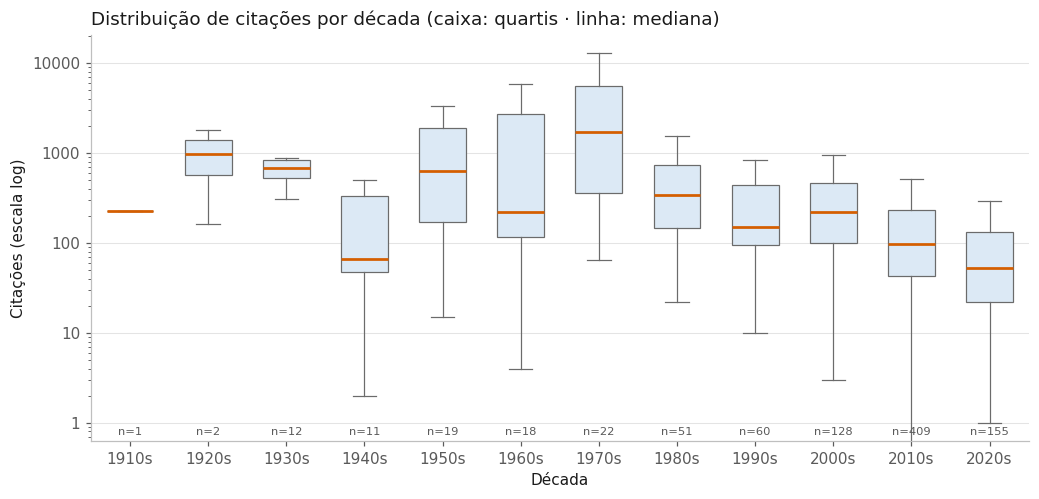

| Década | n | Mediana | 3º quartil | Máximo |
|---|---|---|---|---|
| 1910s | 1 | 228 | 228 | 228 |
| 1920s | 2 | 974 | 164 | 1783 |
| 1930s | 12 | 673 | 811 | 1906 |
| 1940s | 11 | 66 | 325 | 794 |
| 1950s | 19 | 636 | 1734 | 3328 |
| 1960s | 18 | 220 | 2223 | 8352 |
| 1970s | 22 | 1690 | 4536 | 12896 |
| 1980s | 51 | 342 | 707 | 4907 |
| 1990s | 60 | 151 | 427 | 9245 |
| 2000s | 128 | 220 | 466 | 5290 |
| 2010s | 409 | 98 | 233 | 23108 |
| 2020s | 155 | 53 | 132 | 6840 |

In [12]:
por_dec = collections.defaultdict(list)
for r in D: por_dec[r['ano'] // 10 * 10].append(r['cit'])
ks = sorted(por_dec)
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=.9)
ax.boxplot([por_dec[k] for k in ks], positions=range(len(ks)), widths=.6, showfliers=False,
           patch_artist=True, medianprops=dict(color=LARANJA, linewidth=1.8),
           boxprops=dict(facecolor='#DCE9F5', edgecolor=CINZA, linewidth=.8),
           whiskerprops=dict(color=CINZA, linewidth=.8), capprops=dict(color=CINZA, linewidth=.8))
ax.set_yscale('log')
ax.set_xticks(range(len(ks))); ax.set_xticklabels([f'{k}s' for k in ks])
for i, k in enumerate(ks):   # em coordenadas de eixo, para nao cair fora da area visivel
    ax.annotate(f'n={len(por_dec[k])}', (i, .015), xycoords=('data', 'axes fraction'),
                ha='center', fontsize=7.5, color=TINTA2)
ax.set_xlabel('Década'); ax.set_ylabel('Citações (escala log)')
ax.set_title('Distribuição de citações por década (caixa: quartis · linha: mediana)',
             loc='left', color=TINTA)
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.show()

display(Markdown('| Década | n | Mediana | 3º quartil | Máximo |\n|---|---|---|---|---|\n' + '\n'.join(
    f'| {k}s | {len(por_dec[k])} | {statistics.median(por_dec[k]):.0f} | '
    f'{sorted(por_dec[k])[int(.75*(len(por_dec[k])-1))]} | {max(por_dec[k])} |' for k in ks)))

**Descrição do gráfico:**

Gráfico de caixas (boxplot), uma caixa por década: o eixo horizontal é a década, o vertical é o
número de citações, em escala logarítmica. A caixa vai do primeiro ao terceiro quartil, a linha
laranja marca a mediana, os bigodes se estendem até 1,5 vez a amplitude interquartil, e outliers
além desse intervalo não são desenhados. O rótulo *n* abaixo de cada caixa é o número de
referências daquela década. A tabela logo abaixo do gráfico traz os mesmos números por década:
*n*, mediana, terceiro quartil e máximo.

**Peculiaridades do gráfico:**

As medianas desenham uma curva com pico nos anos 1970, 1.690 citações, e caem monotonicamente
depois: 342 nos anos 1980, 151 nos 1990, 98 nos 2010, 53 nos 2020. Parte dessa queda é trivial: um
artigo de 2020 teve cinco anos para acumular citações, um de 1970 teve cinquenta e cinco. É por
isso que a Figura 4 existe.

O que **não** é trivial é a altura das caixas, que mede a dispersão interna de cada década. A razão
entre terceiro e primeiro quartil vai de **1,6×** nos anos 1930 a **20,6×** nos anos 1960 e **13,2×**
nos 1970, e depois se estabiliza em torno de **5×** de 1980 em diante.

A caixa curta dos anos 1930 com *n* = 12 diz que uma review só volta tão atrás para buscar o que
artigos que viram fundamento, tudo que ela cita daquela década é canônico, então a dispersão é pequena. As
caixas altíssimas dos anos 1960 e 1970 são o oposto, ali convivem, na mesma bibliografia, o
Kobayashi–Maskawa com 12.896 citações e trabalhos de instrumentação da época com poucas dezenas. É
a década em que o campo estava se formando e a review precisa citar as duas coisas.

De 1980 em diante a dispersão se estabiliza e o *n* explode, 409 referências só dos anos 2010. A
partir daí a bibliografia deixa de ser seletiva e passa a ser um retrato da literatura corrente.

---
## Figura 4 — Taxa de citação: citações por ano desde a publicação

Este é o gráfico que corrige o efeito de idade. Dividir as citações pelos anos desde a publicação
põe no mesmo plano um clássico que acumulou devagar por cinco décadas e um trabalho recente de
altíssimo impacto.

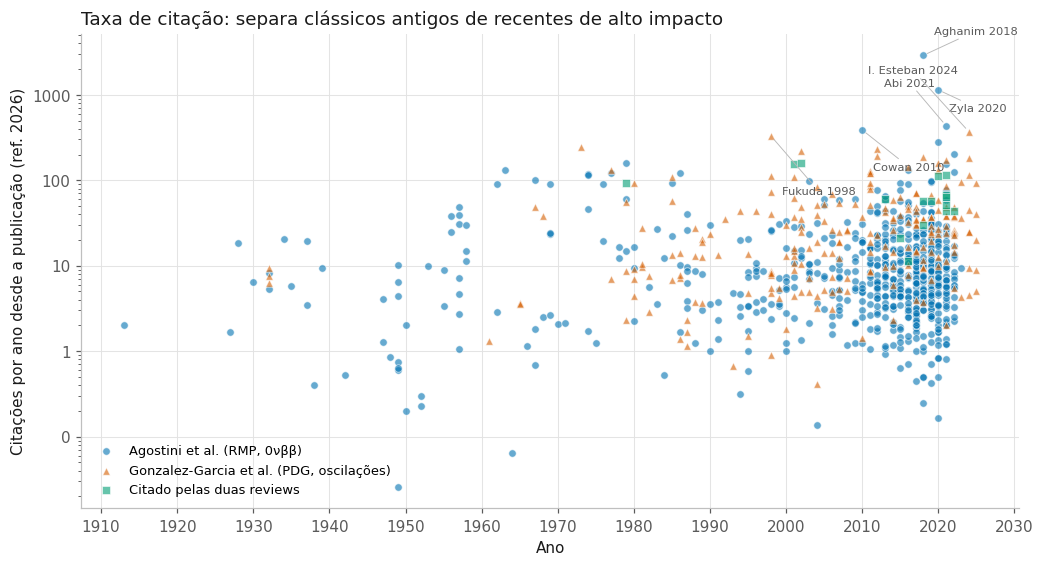

Maiores taxas de citação (citações/ano):
   2888.5/ano ·  23108 cit. em  8 anos · 2018 · Planck 2018 results. VI. Cosmological parameters
   1140.0/ano ·   6840 cit. em  6 anos · 2020 · Review of Particle Physics
    435.6/ano ·   2178 cit. em  5 anos · 2021 · Measurement of the Positive Muon Anomalous Magnetic Moment
    387.3/ano ·   6197 cit. em 16 anos · 2010 · Asymptotic formulae for likelihood-based tests of new phys
    370.5/ano ·    741 cit. em  2 anos · 2024 · NuFit-6.0: updated global analysis of three-flavor neutrin
    330.2/ano ·   9245 cit. em 28 anos · 1998 · Evidence for oscillation of atmospheric neutrinos
    277.5/ano ·   1665 cit. em  6 anos · 2020 · The fate of hints: updated global analysis of three-flavor
    243.3/ano ·  12896 cit. em 53 anos · 1973 · CP Violation in the Renormalizable Theory of Weak Interact
    230.3/ano ·   3224 cit. em 14 anos · 2012 · Observation of electron-antineutrino disappearance at Daya
    220.4/ano ·   5290 cit. em 24 anos · 2002 ·

In [13]:
fig, ax = plt.subplots(figsize=(11, 5.6))
ax.set_axisbelow(True); ax.grid(True, alpha=.9)
for chave, e in ESTILO.items():
    g = [r for r in D if r['fontes'] == chave]
    ax.scatter([r['ano'] for r in g], [r['taxa'] for r in g], s=24, c=e['cor'],
               marker=e['marcador'], alpha=.6, linewidths=.6, edgecolors='white',
               label=e['rotulo'], zorder=3)
ax.set_yscale('log')
ax.set_xlabel('Ano'); ax.set_ylabel(f'Citações por ano desde a publicação (ref. {ANO_REF})')
ax.set_title('Taxa de citação: separa clássicos antigos de recentes de alto impacto',
             loc='left', color=TINTA)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(ScalarFormatter())
rotular(ax, D, lambda r: r['taxa'])
ax.legend(loc='lower left', fontsize=8.5)
plt.show()

print('Maiores taxas de citação (citações/ano):')
for r in sorted(D, key=lambda z: -z['taxa'])[:10]:
    print(f"  {r['taxa']:7.1f}/ano · {r['cit']:>6} cit. em {r['idade']:>2} anos · "
          f"{r['ano']} · {(r['titulo'] or '')[:58]}")

**Descrição do gráfico:**

Gráfico de dispersão: o eixo horizontal é o ano em que o trabalho apareceu, o vertical é a taxa
de citação, citações acumuladas dividido pelos anos desde a publicação, em escala logarítmica.
Cada ponto é uma referência; marcador e cor identificam a review de origem, os mesmos da Figura 1.
Os seis pontos com maior taxa são rotulados com autor e ano, e a lista impressa abaixo do gráfico
traz as dez maiores taxas com o número de citações e a idade do trabalho.

**Peculiaridades do gráfico:**

O Super-Kamiokande de 1998 tem 9.245 citações acumuladas em
28 anos, cerca de 330 por ano. O Planck 2018 tem 23.108 em 8 anos, cerca de 2.900 por ano. Em
citações absolutas o Planck lidera por um fator 2,5; em taxa, por um fator 9. São dois regimes
diferentes de influência.

O padrão geral é uma nuvem aproximadamente horizontal, com a borda superior subindo devagar em
direção ao presente. Isso reflete o crescimento do volume de publicação em física de partículas,
um artigo de hoje é citado por uma comunidade maior do que a de 1970, então taxas altas são mais
fáceis de alcançar agora. Para comparar trabalhos de épocas distintas, **nenhuma das duas métricas
basta sozinha**.

---
## Figura 5 — As 30 referências mais citadas

A mesma informação da Tabela 2 (formato ABNT) em forma visual, com a cor indicando qual
review citou o trabalho.

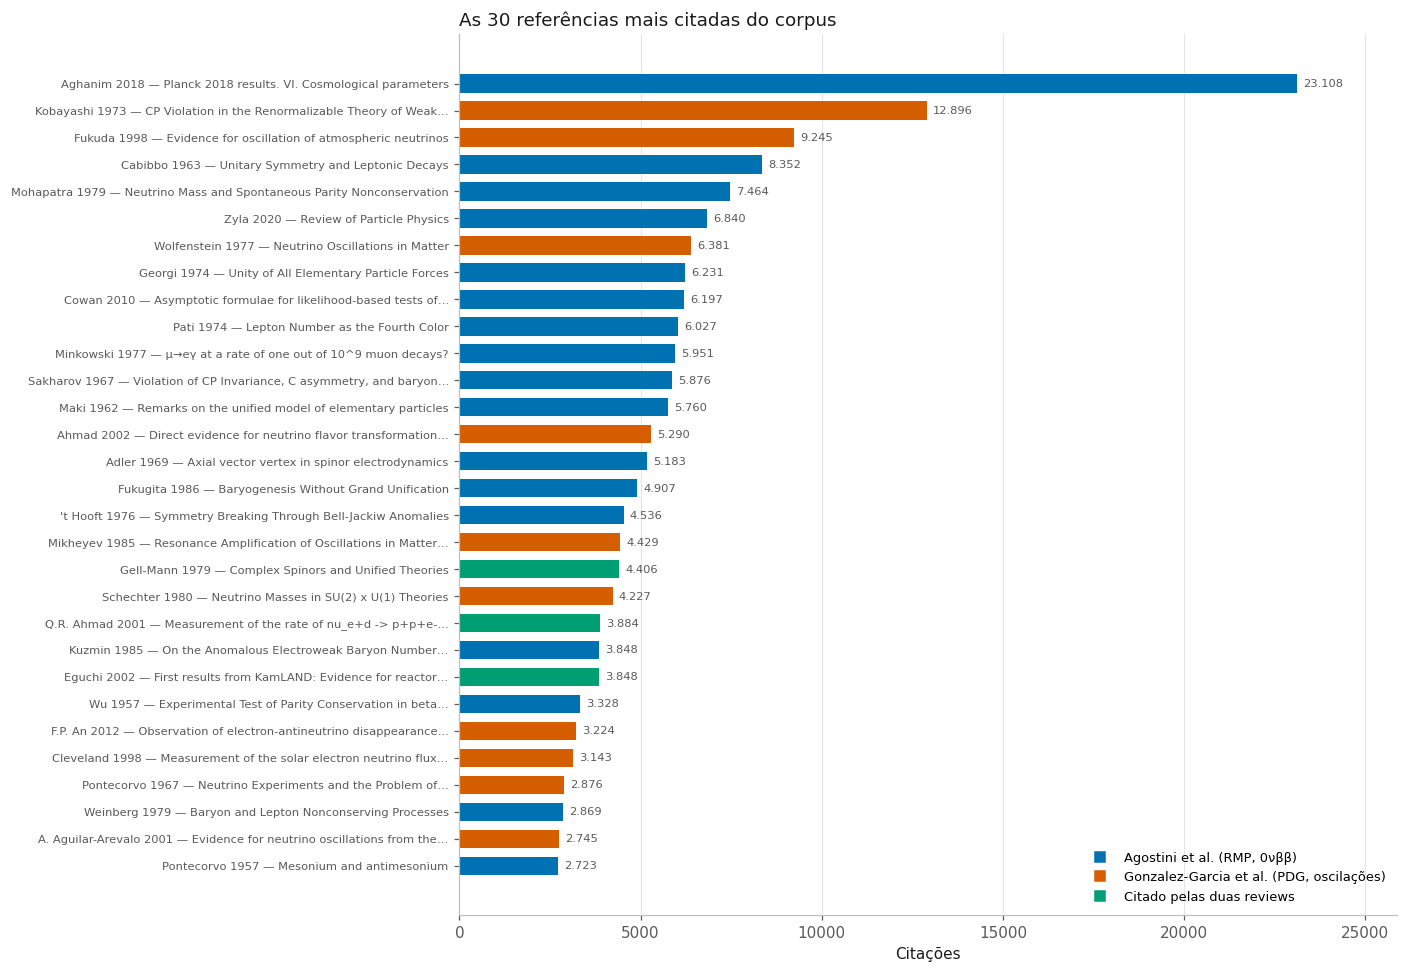

In [14]:
from matplotlib.lines import Line2D
top30 = sorted(D, key=lambda r: -r['cit'])[:30][::-1]
fig, ax = plt.subplots(figsize=(11, 10.4))
ax.set_axisbelow(True); ax.grid(True, axis='x', alpha=.9)
ax.barh(range(len(top30)), [r['cit'] for r in top30],
        color=[ESTILO.get(r['fontes'], {}).get('cor', CINZA) for r in top30], height=.68, linewidth=0)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels([f"{(r['primeiro_autor'] or r['autor_ref']).split(',')[0][:20]} {r['ano']} — "
                    f"{textwrap.shorten(r['titulo'] or '(sem título)', 52, placeholder='…')}"
                    for r in top30], fontsize=7.5)
for i, r in enumerate(top30):
    ax.annotate(f"{r['cit']:,}".replace(',', '.'), (r['cit'], i), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=7.5, color=TINTA2)
ax.set_xlabel('Citações'); ax.margins(x=.12)
ax.set_title('As 30 referências mais citadas dos dados', loc='left', color=TINTA)
presentes = [k for k in ESTILO if any(r['fontes'] == k for r in top30)]
ax.legend(handles=[Line2D([], [], marker='s', linestyle='none', markersize=7,
                          color=ESTILO[k]['cor'], label=ESTILO[k]['rotulo']) for k in presentes],
          loc='lower right', fontsize=8.5)
plt.show()

**Descrição do gráfico:**

Gráfico de barras horizontais com as 30 referências mais citadas, ordenadas de baixo para cima
da 30ª colocada até a mais citada. O eixo horizontal é o número de citações, anotado ao final de
cada barra; cada linha traz o primeiro autor, o ano e um resumo do título. A cor da barra indica
a review de origem, o mesmo esquema de cores das Figuras 1 e 4, identificado na legenda.

**Peculiaridades do gráfico:**

Contando por review, das 30 mais citadas, a maioria vem da bibliografia do Agostini (0νββ), mas os
trabalhos de **oscilação** dominam o topo. Só três das trinta tratam diretamente de decaimento
duplo beta sem neutrinos. As outras vinte e sete são sobre mistura de sabores, mecanismos de massa,
violação de CP, anomalias e assimetria bariônica.

Isso mostra que 0νββ é um campo **jovem e experimental**, cujas bases
conceituais foram estabelecidas por uma literatura mais antiga e mais citada. Os artigos verdes,
citados pelas duas reviews, são precisamente a ponte entre os dois mundos.

---
# Tabela 1 — Referências ligadas ao objetivo da IC

**Descrição da tabela:**

As 157 referências das duas reviews que se relacionam com os objetivos específicos da IC,
selecionadas pela leitura de cada título. A tabela é dividida em nove
eixos. Os cinco primeiros reúnem o **formalismo**: a natureza de Dirac ou de Majorana do neutrino e
a estrutura quiral da interação fraca, a mistura leptônica com as fases de CP, os mecanismos de
massa e a violação do número leptônico, a leptogênese e a teoria da taxa do 0νββ. Os quatro
últimos reúnem o que é **diretamente correlacionado**: a fenomenologia da massa efetiva
$m_{\beta\beta}$, as revisões sobre 0νββ, os limites experimentais sobre $m_{\beta\beta}$ e a escala
absoluta de massa, e a evidência de massa com os parâmetros de oscilação que entram em
$m_{\beta\beta}$.

Dentro de cada eixo, as referências seguem a ordem cronológica, e o ano é o `earliest_date` do
INSPIRE. As seis referências sem registro na base aparecem com "—" na coluna de citações e com o
ano da bibliografia. Ficaram de fora instrumentação, background, 2νββ, cálculos individuais de
elemento de matriz nuclear, mecanismos alternativos de 0νββ (supersimetria, modelos left-right,
operadores de teoria efetiva), oscilação em matéria, anomalias de neutrinos estéreis e resultados
de 0νββ superados pelo resultado final do mesmo experimento. A seleção está registrada em
`scripts/tema/refs_ic.py` e salva em `dados/ic/referencias_ic.csv`.

In [19]:
IC = list(csv.DictReader(open('dados/ic/referencias_ic.csv', encoding='utf-8')))
for r in IC:
    r['ano'] = int(r['ano'])
    r['cit'] = int(r['citacoes']) if r['citacoes'].isdigit() else None

def celula(r):
    etal = ' *et al.*' if r['n_autores'].isdigit() and int(r['n_autores']) > 1 else '.'
    titulo = r['titulo'].replace('|', '/').rstrip('. ')
    jor = r['journal'].replace('|', ', ').strip().rstrip('. ')
    return f"**{r['primeiro_autor'].upper()}**{etal} {titulo}" + (f". *{jor}*" if jor else '')

def citacoes(r):
    return f"{r['cit']:,}".replace(',', '.') if r['cit'] is not None else '—'

blocos = []
for n in range(1, 10):
    g = sorted((r for r in IC if r['eixo_num'] == str(n)), key=lambda r: (r['ano'], r['primeiro_autor']))
    eixo = g[0]['eixo'].replace('m_ββ', r'$m_{\beta\beta}$')
    linhas = '\n'.join(f"| {r['ano']} | {citacoes(r)} | {celula(r)} |" for r in g)
    blocos.append(f"### 1.{n} — {eixo}\n\n*{g[0]['tipo']}* · {len(g)} referências\n\n"
                  f"| Ano | Citações | Trabalho |\n|---:|---:|---|\n{linhas}")
display(Markdown('\n\n'.join(blocos)))

tipos = collections.Counter(r['tipo'] for r in IC)
print(f"{len(IC)} referências · formalismo {tipos['Formalismo']} · diretamente correlacionadas {tipos['Direta']} · "
      f"{sum(r['cit'] is None for r in IC)} sem registro no INSPIRE")

### 1.1 — Natureza do neutrino: Dirac, Majorana e quiralidade

*Formalismo* · 21 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 1928 | 1.783 | **DIRAC**. The quantum theory of the electron. *Proc. Roy. Soc. Lond. A 117, 610-624* |
| 1937 | 1.720 | **MAJORANA**. Teoria simmetrica dell'elettrone e del positrone. *Nuovo Cim. 14, 171-184* |
| 1937 | 305 | **RACAH**. On the symmetry of particle and antiparticle. *Nuovo Cim. 14, 322-328* |
| 1938 | 35 | **FURRY**. Note on the Theory of the Neutral Particle. *Phys. Rev. 54, 56-67* |
| 1955 | 241 | **DAVIS**. Attempt to detect the antineutrinos from a nuclear reactor by the Cl37(anti-nu,e-) A37 reaction. *Phys.Rev. 97, 766* |
| 1957 | 186 | **CASE**. Reformulation of the Majorana Theory of the Neutrino. *Phys.Rev. 107, 307* |
| 1957 | 74 | **LANDAU**. On the conservation laws for weak interactions. *Nucl.Phys. 3, 127* |
| 1957 | 492 | **LEE** *et al.* Parity Nonconservation and a Two Component Theory of the Neutrino. *Phys. Rev. 105, 1671* |
| 1957 | — | **RADICATI** *et al.* On the equivalence theorem for the massless neutrino. *Nuovo Cim. Series 10, 5, 1693* |
| 1957 | 322 | **SALAM**. On parity conservation and neutrino mass. *Nuovo Cim. 5, 299* |
| 1958 | 2.053 | **FEYNMAN** *et al.* Theory of Fermi interaction. *Phys. Rev. 109, 193* |
| 1958 | 999 | **GOLDHABER** *et al.* Helicity of Neutrinos. *Phys. Rev. 109, 1015* |
| 1958 | 773 | **SUDARSHAN** *et al.* Chirality invariance and the universal Fermi interaction. *Phys. Rev. 109, 1860* |
| 1981 | 433 | **SCHECHTER** *et al.* Majorana Neutrinos and Magnetic Fields. *Phys. Rev. D24, 1883* |
| 1987 | 45 | **KAYSER** *et al.* The Physics of Massive Neutrinos. *World Sci. Lect. Notes Phys. 25, 1 (1989)* |
| 1993 | 22 | **KIM** *et al.* Neutrinos in physics and astrophysics. *Contemp. Concepts Phys. 8, 1* |
| 1998 | 153 | **MOHAPATRA** *et al.* Massive neutrinos in physics and astrophysics. Second edition. *World Sci. Lect. Notes Phys. 60, 1* |
| 2007 | 469 | **GIUNTI** *et al.* Fundamentals of Neutrino Physics and Astrophysics. *ISBN 9780198508717 (Oxford Univ. Press)* |
| 2013 | 80 | **PETCOV**. The Nature of Massive Neutrinos. *Adv.High Energy Phys.,2013,852987* |
| 2014 | 528 | **ELLIOTT** *et al.* Colloquium: Majorana Fermions in nuclear, particle and solid-state physics. *Rev.Mod.Phys.,87,137* |
| 2018 | — | **DE BIANCHI**. Rethinking antiparticles. Hermann Weyl’s contribution to neutrino physics. *Stud.Hist.Phil.Sci.B 61, 68-79* |

### 1.2 — Mistura leptônica, matriz PMNS e fases de CP

*Formalismo* · 19 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 1957 | 2.150 | **PONTECORVO**. Inverse Beta Processes and Nonconservation of Lepton Charge. *Zh. Eksp. Teor. Fiz. 34, 247* |
| 1957 | 2.723 | **PONTECORVO**. Mesonium and antimesonium. *Sov. Phys. JETP 6, 429* |
| 1962 | 184 | **KATAYAMA** *et al.* Possible unified models of elementary particles with two neutrinos. *Prog. Theor. Phys. 28, 675* |
| 1962 | 5.760 | **MAKI** *et al.* Remarks on the unified model of elementary particles. *Prog. Theor. Phys. 28, 870* |
| 1963 | 8.352 | **CABIBBO**. Unitary Symmetry and Leptonic Decays. *Phys. Rev. Lett. 10, 531* |
| 1967 | 2.876 | **PONTECORVO**. Neutrino Experiments and the Problem of Conservation of Leptonic Charge. *Zh.Eksp.Teor.Fiz. 53, 1717* |
| 1969 | 1.365 | **GRIBOV** *et al.* Neutrino astronomy and lepton charge. *Phys.Lett.B 28, 493* |
| 1973 | 12.896 | **KOBAYASHI** *et al.* CP Violation in the Renormalizable Theory of Weak Interaction. *Prog.Theor.Phys. 49, 652* |
| 1977 | 343 | **CABIBBO**. Time Reversal Violation in Neutrino Oscillation. *Phys. Lett. 72B, 333* |
| 1979 | 109 | **SCHECHTER** *et al.* Comment on the Lepton Mixing Matrix. *Phys. Rev. D21, 309* |
| 1980 | 203 | **BARGER** *et al.* CP Nonconservation in Three-Neutrino Oscillations. *Phys. Rev. Lett. 45, 2084* |
| 1980 | 759 | **BILENKY** *et al.* On Oscillations of Neutrinos with Dirac and Majorana Masses. *Phys.Lett.B 94, 495* |
| 1985 | 2.328 | **JARLSKOG**. Commutator of the Quark Mass Matrices in the Standard Electroweak Model and a Measure of Maximal CP Violation. *Phys. Rev. Lett. 55, 1039* |
| 2002 | 118 | **FARZAN** *et al.* Leptonic unitarity triangle and CP violation. *Phys. Rev. D65, 113001* |
| 2002 | 599 | **GONZALEZ-GARCIA** *et al.* Neutrino Masses and Mixing: Evidence and Implications. *Rev. Mod. Phys. 75, 345* |
| 2006 | 530 | **ANTUSCH** *et al.* Unitarity of the Leptonic Mixing Matrix. *JHEP,0610,084* |
| 2007 | 1.028 | **GONZALEZ-GARCIA** *et al.* Phenomenology with Massive Neutrinos. *Phys.Rept.,460,1* |
| 2010 | 23 | **DUECK** *et al.* On Leptonic Unitary Triangles and Boomerangs. *Phys.Rev.D,82,013005* |
| 2014 | 317 | **ANTUSCH** *et al.* Non-unitarity of the leptonic mixing matrix: present bounds and future sensitivities. *JHEP,10,094* |

### 1.3 — Geração de massa (seesaw) e violação do número leptônico

*Formalismo* · 17 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 1953 | — | **MARX**. Die wechselwirkung der elementar-teilchen und die erhaltungssätze. *Acta Phys.Acad.Sci.Hung. 3, 55-58 (bruto)* |
| 1977 | 5.951 | **MINKOWSKI**. μ→eγ at a rate of one out of 10^9 muon decays?. *Phys.Lett.B 67, 421* |
| 1979 | 4.406 | **GELL-MANN** *et al.* Complex Spinors and Unified Theories |
| 1979 | 7.464 | **MOHAPATRA** *et al.* Neutrino Mass and Spontaneous Parity Nonconservation. *Phys.Rev.Lett. 44, 912* |
| 1979 | 2.869 | **WEINBERG**. Baryon and Lepton Nonconserving Processes. *Phys.Rev.Lett. 43, 1566* |
| 1979 | 2.623 | **YANAGIDA**. Horizontal gauge symmetry and masses of neutrinos. *Conf. Proc. C 7902131, 95* |
| 1980 | 4.227 | **SCHECHTER** *et al.* Neutrino Masses in SU(2) x U(1) Theories. *Phys. Rev. D22, 2227* |
| 1980 | 432 | **WEINBERG**. Varieties of Baryon and Lepton Nonconservation. *Phys. Rev. D 22, 1694* |
| 1991 | 465 | **PILAFTSIS**. Radiatively induced neutrino masses and large Higgs neutrino couplings in the standard model with Majorana fields. *Z.Phys. C55, 275* |
| 1993 | — | **ZELDOVICH** *et al.* On the theory of elementary particles.: Conservation of the nuclear charge and a possible new type of v-particles. *Selected Works of Yakov Borisovich Zeldovich, Vol. II (Princeton University Press), pp. 56-61* |
| 2001 | 266 | **BABU** *et al.* Classification of effective neutrino mass operators. *Nucl.Phys.B619,667* |
| 2005 | 1.090 | **ASAKA** *et al.* The nuMSM, dark matter and neutrino masses. *Phys. Lett. B 631, 151* |
| 2007 | 225 | **DE GOUVEA** *et al.* A Survey of Lepton Number Violation Via Effective Operators. *Phys.Rev.D 77, 013008* |
| 2009 | 1.027 | **ATRE** *et al.* The Search for Heavy Majorana Neutrinos. *JHEP,0905,030* |
| 2013 | 415 | **DREWES**. The Phenomenology of Right Handed Neutrinos. *Int.J.Mod.Phys.E,22,1330019* |
| 2013 | 256 | **DE GOUVEA** *et al.* Lepton Flavor and Number Conservation, and Physics Beyond the Standard Model. *Prog.Part.Nucl.Phys. 71, 75-92* |
| 2015 | 628 | **DEPPISCH** *et al.* Neutrinos and Collider Physics. *New J.Phys.,17,075019* |

### 1.4 — Leptogênese e assimetria bariônica

*Formalismo* · 14 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 1967 | 5.876 | **SAKHAROV**. Violation of CP Invariance, C asymmetry, and baryon asymmetry of the universe. *Pisma Zh.Eksp.Teor.Fiz. 5, 32* |
| 1976 | 4.536 | **'T HOOFT**. Symmetry Breaking Through Bell-Jackiw Anomalies. *Phys.Rev.Lett. 37, 8-11* |
| 1985 | 3.848 | **KUZMIN** *et al.* On the Anomalous Electroweak Baryon Number Nonconservation in the Early Universe. *Phys. Lett. B 155, 36* |
| 1986 | 4.907 | **FUKUGITA** *et al.* Baryogenesis Without Grand Unification. *Phys. Lett. B 174, 45* |
| 1990 | 1.066 | **HARVEY** *et al.* Cosmological Baryon and Lepton Number in the Presence of Electroweak Fermion Number Violation. *Phys. Rev. D 42, 3344-3349 (1990)* |
| 1998 | 715 | **AKHMEDOV** *et al.* Baryogenesis via neutrino oscillations. *Phys.Rev.Lett. 81, 1359* |
| 2009 | 36 | **SHAPOSHNIKOV**. Baryogenesis. *J. Phys. Conf. Ser. 171, 012005* |
| 2015 | 88 | **DEPPISCH** *et al.* Falsifying High-Scale Baryogenesis with Neutrinoless Double Beta Decay and Lepton Flavor Violation. *Phys.Rev.D,92,036005* |
| 2016 | 72 | **DREWES** *et al.* Neutrinoless double β decay and low scale leptogenesis. *Phys.Lett.B,763,72-79* |
| 2016 | 164 | **HERNÁNDEZ** *et al.* Testable Baryogenesis in Seesaw Models. *JHEP 08, 157* |
| 2017 | 89 | **DEPPISCH** *et al.* Neutrinoless Double Beta Decay and the Baryon Asymmetry of the Universe. *Phys. Rev. D 98, 055029* |
| 2017 | 130 | **DREWES** *et al.* Testing the low scale seesaw and leptogenesis. *JHEP,08,018* |
| 2022 | 30 | **DREWES** *et al.* Low-scale leptogenesis with flavour and CP symmetries |
| 2022 | 94 | **DREWES** *et al.* Mapping the Viable Parameter Space for Testable Leptogenesis. *Phys.Rev.Lett. 128, 051801* |

### 1.5 — 0νββ: formalismo da taxa e da massa efetiva

*Formalismo* · 17 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 1934 | 1.906 | **FERMI**. An attempt of a theory of beta radiation. 1. *Z. Phys. 88, 161-177* |
| 1935 | 532 | **GOEPPERT-MAYER**. Double beta-disintegration. *Phys. Rev. 48, 512-516* |
| 1939 | 811 | **FURRY**. On transition probabilities in double beta-disintegration. *Phys. Rev. 56, 1184-1193* |
| 1948 | — | **TOUSCHEK**. Zur theorie des doppelten β-zerfalls. *Z. Phys. 125, 108-132 (1948)* |
| 1960 | — | **GREULING** *et al.* Lepton conservation and double beta-decay. *Annals Phys. 11, 510* |
| 1968 | 144 | **PONTECORVO**. Superweak interactions and double beta decay. *Phys.Lett.B 26, 630* |
| 1969 | 151 | **PRIMAKOFF** *et al.* Nuclear double-beta decay and a new limit on lepton nonconservation. *Phys.Rev. 184, 1925* |
| 1981 | 1.248 | **SCHECHTER** *et al.* Neutrinoless Double beta Decay in SU(2) x U(1) Theories. *Phys. Rev. D 25, 2951* |
| 1985 | 922 | **DOI** *et al.* Double beta Decay and Majorana Neutrino. *Prog. Theor. Phys. Suppl. 83, 1* |
| 1998 | 723 | **SUHONEN** *et al.* Weak-interaction and nuclear-structure aspects of nuclear double beta decay. *Phys. Rept. 300, 123-214* |
| 2011 | 158 | **DUERR** *et al.* On the Quantitative Impact of the Schechter-Valle Theorem. *JHEP06,091* |
| 2012 | 696 | **KOTILA** *et al.* Phase space factors for double-beta decay. *Phys.Rev.C,85,034316* |
| 2012 | 585 | **VERGADOS** *et al.* Theory of Neutrinoless Double Beta Decay. *Rept.Prog.Phys.,75,106301* |
| 2017 | 106 | **CIRIGLIANO** *et al.* Neutrinoless double-β decay in effective field theory: The light-Majorana neutrino-exchange mechanism. *Phys. Rev. C 97, 065501* |
| 2017 | 643 | **ENGEL** *et al.* Status and Future of Nuclear Matrix Elements for Neutrinoless Double-Beta Decay: A Review. *Rept.Prog.Phys.,80,046301* |
| 2018 | 207 | **CIRIGLIANO** *et al.* New Leading Contribution to Neutrinoless Double-β Decay. *Phys. Rev. Lett. 120, 202001* |
| 2022 | 49 | **CIRIGLIANO**. Towards precise and accurate calculations of neutrinoless double-beta decay |

### 1.6 — Fenomenologia da massa efetiva $m_{\beta\beta}$

*Direta* · 24 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 1999 | 196 | **VISSANI**. Signal of neutrinoless double beta decay, neutrino spectrum and oscillation scenarios. *JHEP 06,022* |
| 2000 | 47 | **VISSANI**. Nonoscillation searches of neutrino mass in the age of oscillations. *Nucl.Phys.B Proc.Suppl.100,273* |
| 2002 | 366 | **FERUGLIO** *et al.* Neutrino oscillations and signals in beta and 0nu2beta experiments. *Nucl. Phys. B637, 345* |
| 2004 | 81 | **BAHCALL** *et al.* What can we learn from neutrinoless double beta decay experiments?. *Phys. Rev. D 70, 033012* |
| 2004 | 180 | **FOGLI** *et al.* Observables sensitive to absolute neutrino masses: Constraints and correlations from world neutrino data. *Phys.Rev.D 70, 113003* |
| 2005 | 66 | **BEZRUKOV**. nu MSM-predictions for neutrinoless double beta decay. *Phys. Rev. D 72, 071303* |
| 2010 | 233 | **BLENNOW** *et al.* Neutrinoless double beta decay in seesaw models. *JHEP 07, 096* |
| 2010 | 48 | **SIMKOVIC** *et al.* Few active mechanisms of the neutrinoless double beta-decay and effective mass of Majorana neutrinos. *Phys.Rev.D,82,113015* |
| 2011 | 239 | **MITRA** *et al.* Neutrinoless Double Beta Decay and Heavy Sterile Neutrinos. *Nucl.Phys.B,856,26* |
| 2013 | 137 | **BHUPAL DEV** *et al.* Constraining Neutrino Mass from Neutrinoless Double Beta Decay. *Phys. Rev. D 88, 091301* |
| 2014 | 121 | **FAESSLER** *et al.* Arbitrary mass Majorana neutrinos in neutrinoless double beta decay. *Phys. Rev. D 90, 096010* |
| 2015 | 20 | **AGOSTINI** *et al.* Probing flavor models with Ge-76-based experiments on neutrinoless double-beta decay. *Eur.Phys.J.C,76,176* |
| 2015 | 58 | **BENATO**. Effective Majorana Mass and Neutrinoless Double Beta Decay. *Eur.Phys.J.C,75,563* |
| 2015 | 47 | **DELL'ORO** *et al.* The contribution of light Majorana neutrinos to neutrinoless double beta decay and cosmology. *JCAP,12,023* |
| 2017 | 209 | **AGOSTINI** *et al.* Discovery probability of next-generation neutrinoless double-β decay experiments. *Phys.Rev.D,96,053001* |
| 2017 | 73 | **CALDWELL** *et al.* Global Bayesian analysis of neutrino mass data. *Phys.Rev.D,96,073001* |
| 2017 | 4 | **DELL'ORO** *et al.* Testing creation of matter with neutrinoless double beta decay |
| 2018 | 4 | **DELL’ORO** *et al.* Search for creation of electrons in lab. *J. Phys. Conf. Ser. 1056, 012059* |
| 2019 | 256 | **BOLTON** *et al.* Neutrinoless double beta decay versus other probes of heavy sterile neutrinos. *JHEP 03 (2020) 170* |
| 2020 | 10 | **AGOSTINI**. Discovery probabilities of Majorana neutrinos based on cosmological data. *Phys.Rev.D 103, 033008* |
| 2021 | 32 | **AGOSTINI**. Testing the inverted neutrino mass ordering with neutrinoless double-beta decay. *Phys.Rev.C 104, L042501* |
| 2021 | 10 | **VISSANI**. What Is Matter According to Particle Physics, and Why Try to Observe Its Creation in a Lab?. *Universe 7, 61* |
| 2022 | 9 | **ETTENGRUBER** *et al.* Discovering neutrinoless double-beta decay in the era of precision neutrino cosmology |
| 2022 | 13 | **LISI** *et al.* Majorana neutrino mass constraints in the landscape of nuclear matrix elements. *Phys.Rev.D 106, 013009* |

### 1.7 — Revisões sobre 0νββ

*Direta* · 16 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 2004 | 240 | **ELLIOTT** *et al.* Double beta decay. *J. Phys. G 30, R183* |
| 2007 | 1.104 | **AVIGNONE** *et al.* Double Beta Decay, Majorana Neutrinos, and Neutrino Mass. *Rev.Mod.Phys.,80,481* |
| 2011 | 95 | **BARABASH**. Double Beta Decay: Historical Review of 75 Years of Research. *Phys.Atom.Nucl.,74,603* |
| 2011 | 251 | **GOMEZ-CADENAS** *et al.* The Search for neutrinoless double beta decay. *Riv.Nuovo Cim.,35,29-98* |
| 2011 | 661 | **RODEJOHANN**. Neutrino-less Double Beta Decay and Particle Physics. *Int.J.Mod.Phys.E20,1833* |
| 2012 | 287 | **DEPPISCH** *et al.* Neutrinoless Double Beta Decay and Physics Beyond the Standard Model. *J.Phys.G39,124007* |
| 2012 | 85 | **ELLIOTT**. Recent Progress in Double Beta Decay. *Mod.Phys.Lett.A27,1230009* |
| 2012 | 144 | **GIULIANI** *et al.* Neutrinoless Double-Beta Decay. *Adv. High Energy Phys. 2012, 857016* |
| 2012 | 254 | **RODEJOHANN**. Neutrinoless double beta decay and neutrino physics. *J.Phys.G,39,124008* |
| 2012 | 90 | **SCHWINGENHEUER**. Status and prospects of searches for neutrinoless double beta decay. *Annalen Phys.,525,269* |
| 2013 | 171 | **CREMONESI** *et al.* Challenges in Double Beta Decay. *Adv.High Energy Phys.,2014,951432* |
| 2014 | 274 | **BILENKY** *et al.* Neutrinoless Double-Beta Decay: a Probe of Physics Beyond the Standard Model. *Int.J.Mod.Phys.A,30,1530001* |
| 2015 | 153 | **PÄS** *et al.* Neutrinoless Double Beta Decay. *New J.Phys. 17, 115010* |
| 2016 | 508 | **DELL'ORO** *et al.* Neutrinoless double beta decay: 2015 review. *Adv.High Energy Phys.,2016,2162659* |
| 2019 | 678 | **DOLINSKI** *et al.* Neutrinoless Double-Beta Decay: Status and Prospects. *Ann.Rev.Nucl.Part.Sci.,69,219* |
| 2019 | 84 | **GIULIANI** *et al.* Double Beta Decay APPEC Committee Report |

### 1.8 — Limites experimentais sobre $m_{\beta\beta}$ e escala absoluta de massa

*Direta* · 19 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 2001 | 703 | **KLAPDOR-KLEINGROTHAUS** *et al.* Evidence for neutrinoless double beta decay. *Mod.Phys.Lett.A16,2409* |
| 2002 | 299 | **AALSETH** *et al.* Comment on 'Evidence for Neutrinoless Double Beta Decay'. *Mod. Phys. Lett. A17, 1475* |
| 2004 | 688 | **KLAPDOR-KLEINGROTHAUS** *et al.* Search for neutrinoless double beta decay with enriched Ge-76 in Gran Sasso 1990-2003. *Phys. Lett. B 586, 198* |
| 2012 | 594 | **GANDO** *et al.* Limit on Neutrinoless $\beta\beta$ Decay of $^{136}$Xe from the First Phase of KamLAND-Zen and Comparison with the Positive Claim in $^{76}$Ge. *Phys.Rev.Lett.,110,062502* |
| 2013 | 763 | **AGOSTINI** *et al.* Results on Neutrinoless Double-beta Decay of 76Ge from Phase I of the GERDA Experiment. *Phys.Rev.Lett.,111,122503* |
| 2015 | 230 | **ARNOLD** *et al.* Results of the search for neutrinoless double-β decay in 100Mo with the NEMO-3 experiment. *Phys.Rev.D,92,072011* |
| 2016 | 1.336 | **GANDO**. Search for Majorana Neutrinos near the Inverted Mass Hierarchy Region with KamLAND-Zen. *Phys.Rev.Lett.,117,082503* |
| 2018 | 23.108 | **AGHANIM**. Planck 2018 results. VI. Cosmological parameters |
| 2019 | 403 | **ANTON**. Search for Neutrinoless Double-Beta Decay with the Complete EXO-200 Dataset. *Phys.Rev.Lett.,123,161802* |
| 2020 | 666 | **AGOSTINI**. Final Results of GERDA on the Search for Neutrinoless Double-β Decay. *Phys.Rev.Lett.,125,252502* |
| 2021 | 260 | **ADAMS**. Search for Majorana neutrinos exploiting millikelvin cryogenics with CUORE. *Nature 604, 53* |
| 2021 | 146 | **DI VALENTINO** *et al.* Most constraining cosmological neutrino mass bounds. *Phys. Rev. D 104 (8), 083504* |
| 2022 | 498 | **ABE**. Search for the Majorana Nature of Neutrinos in the Inverted Mass Ordering Region with KamLAND-Zen |
| 2022 | 177 | **ARNQUIST**. Final Result of the Majorana Demonstrator's Search for Neutrinoless Double-β Decay in 76Ge |
| 2022 | 105 | **AUGIER**. Final results on the 0νββ decay half-life limit of 100Mo from the CUPID-Mo experiment. *Eur.Phys.J.C 82, 1033* |
| 2022 | 100 | **AZZOLINI**. Final Result on the Neutrinoless Double Beta Decay of $^{82}$Se with CUPID-0. *Phys.Rev.Lett. 129, 111801* |
| 2024 | 230 | **ABE**. Search for Majorana Neutrinos with the Complete KamLAND-Zen Dataset |
| 2024 | 50 | **AGRAWAL**. Improved limit on neutrinoless double beta decay of 100Mo from AMoRE-I. *Phys. Rev. Lett. 134, 8, 082501* |
| 2024 | 362 | **AKER**. Direct neutrino-mass measurement based on 259 days of KATRIN data. *Science 388, 6743, adq9592* |

### 1.9 — Evidência de massa e parâmetros de oscilação

*Direta* · 10 referências

| Ano | Citações | Trabalho |
|---:|---:|---|
| 1998 | 9.245 | **FUKUDA** *et al.* Evidence for oscillation of atmospheric neutrinos. *Phys.Rev.Lett. 81, 1562* |
| 2001 | 3.884 | **AHMAD** *et al.* Measurement of the rate of nu_e+d -> p+p+e- interactions produced by 8B solar neutrinos at the Sudbury Neutrino Observatory. *Phys.Rev.Lett.87,071301* |
| 2002 | 5.290 | **AHMAD** *et al.* Direct evidence for neutrino flavor transformation from neutral current interactions in the Sudbury Neutrino Observatory. *Phys. Rev. Lett. 89, 011301* |
| 2012 | 3.224 | **AN** *et al.* Observation of electron-antineutrino disappearance at Daya Bay. *Phys.Rev.Lett.108,171803* |
| 2014 | 699 | **GONZALEZ-GARCIA** *et al.* Updated fit to three neutrino mixing: status of leptonic CP violation. *JHEP,11,052* |
| 2020 | 1.665 | **ESTEBAN** *et al.* The fate of hints: updated global analysis of three-flavor neutrino oscillations. *JHEP 09 (2020) 178* |
| 2020 | 959 | **DE SALAS**. 2020 global reassessment of the neutrino oscillation picture. *JHEP 02, 071* |
| 2021 | 295 | **CAPOZZI** *et al.* The unfinished fabric of the three neutrino paradigm. *Phys.Rev.D 104, 083031* |
| 2024 | 741 | **ESTEBAN**. NuFit-6.0: updated global analysis of three-flavor neutrino oscillations. *JHEP 12, 216* |
| 2025 | 93 | **CAPOZZI**. Neutrino masses and mixing: Entering the era of subpercent precision. *Phys. Rev. D 111, 9, 093006* |

157 referências · formalismo 88 · diretamente correlacionadas 69 · 6 sem registro no INSPIRE


**Peculiaridades da tabela:**

A seleção reúne 17% das 888 referências com citação, mas concentra 19 das 30 mais citadas de todos
os dados. O formalismo domina em número, 88 contra 69, e em impacto: a mediana é de 529 citações,
contra 230 das diretamente correlacionadas e 124 dos dados inteiros.

Os dois grupos vêm de épocas diferentes. O ano mediano é 1985 no formalismo e 2015 nas
correlacionadas; nenhuma referência direta é anterior a 1998, e 55 das 69 são de 2010 em diante.
Dividindo as citações pela idade, a diferença desaparece: a taxa mediana é de 19,5 citações por
ano no formalismo e 20,9 nas correlacionadas. A distância em citações absolutas é efeito de idade.

A divisão entre as reviews acompanha os objetivos da IC. A do Agostini fornece 115 das 157
referências e cobre sozinha a leptogênese (14 de 14) e as revisões sobre 0νββ (16 de 16), além de
quase toda a fenomenologia de $m_{\beta\beta}$ (23 de 24). A do Gonzalez-Garcia só é maioria em dois
eixos: a matriz PMNS com as fases de CP (12 de 19) e a evidência de massa com os parâmetros de
oscilação (7 de 10).

O eixo com a maior mediana de citações é o da evidência de massa (1.312), puxado por
Super-Kamiokande, SNO e Daya Bay. O de menor mediana é o da fenomenologia de $m_{\beta\beta}$ (62),
com trabalhos de 4 a 366 citações: é a literatura mais próxima do objeto da IC e também a mais
recente.

A leitura dos títulos corrige bastante a classificação automática por palavras-chave
(`scripts/tema/classificar_tema.py`). Das 151 referências com citação desta tabela, só 76 estavam
no núcleo automático, e 184 referências daquele núcleo ficaram de fora depois da leitura.

---
## Figura 6 — Ano × impacto de citação das referências da IC

**Tarefa**: como se distribuem, no tempo e em citações, as referências ligadas ao objetivo da IC?

**Objetivo**: comparar o formalismo com a literatura diretamente correlacionada e verificar se a
diferença de citações entre os dois grupos é de impacto ou de idade.

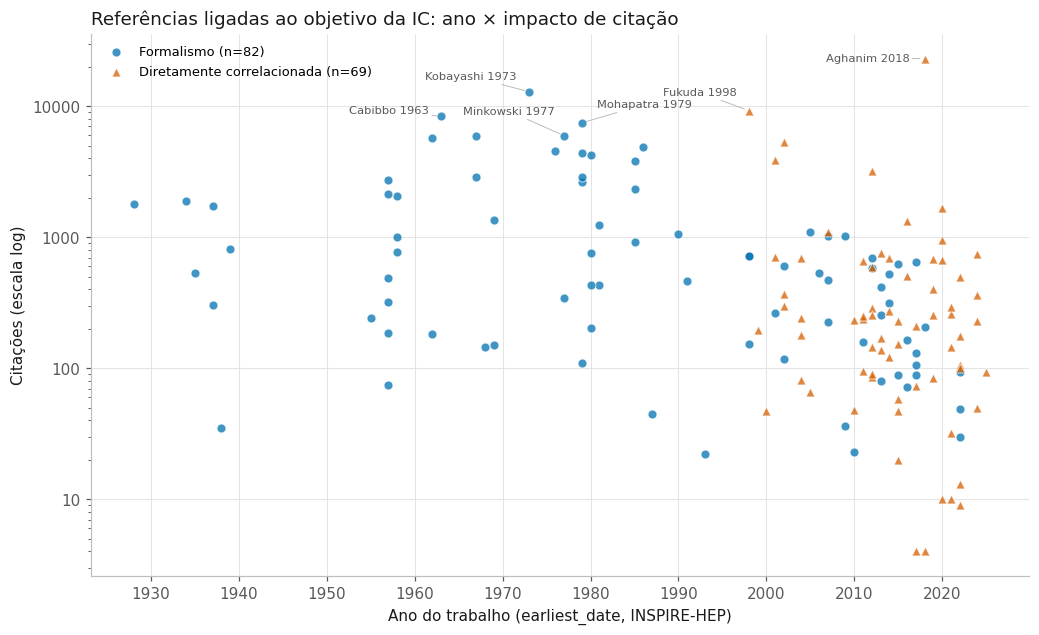

Formalismo: mediana 529 citações · ano mediano 1985 · taxa mediana 19.5 citações/ano
Diretamente correlacionada: mediana 230 citações · ano mediano 2015 · taxa mediana 20.9 citações/ano


In [20]:
IC_cit = [r for r in IC if r['cit'] is not None]
ESTILO_IC = {'Formalismo': dict(cor=AZUL,    marcador='o', rotulo='Formalismo'),
             'Direta':     dict(cor=LARANJA, marcador='^', rotulo='Diretamente correlacionada')}
fig, ax = plt.subplots(figsize=(11, 6.4))
ax.set_axisbelow(True); ax.grid(True, alpha=.9)
for tipo, e in ESTILO_IC.items():
    g = [r for r in IC_cit if r['tipo'] == tipo]
    ax.scatter([r['ano'] for r in g], [r['cit'] for r in g], s=34, c=e['cor'], marker=e['marcador'],
               alpha=.75, linewidths=.6, edgecolors='white', label=f"{e['rotulo']} (n={len(g)})", zorder=3)
ax.set_yscale('log')
ax.set_xlabel('Ano do trabalho (earliest_date, INSPIRE-HEP)')
ax.set_ylabel('Citações (escala log)')
ax.set_title('Referências ligadas ao objetivo da IC: ano × impacto de citação', loc='left', color=TINTA)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(ScalarFormatter())
# posições fixas por ordem de citação: a alternância de rotular() faz Mohapatra cruzar Kobayashi aqui
posicoes = [(-10, 0, 'right'), (-8, 10, 'right'), (-8, 12, 'right'), (-8, 4, 'right'), (10, 12, 'left'), (-6, 16, 'right')]
for r, (dx, dy, ha) in zip(sorted(IC_cit, key=lambda r: -r['cit']), posicoes):
    ax.annotate(f"{r['primeiro_autor']} {r['ano']}", (r['ano'], r['cit']), textcoords='offset points',
                xytext=(dx, dy), ha=ha, va='center', fontsize=7.5, color=TINTA2, zorder=5,
                arrowprops=dict(arrowstyle='-', lw=.6, color='#B8B8B8', shrinkA=0, shrinkB=3))
ax.legend(loc='upper left', fontsize=8.5)
plt.show()

for tipo, e in ESTILO_IC.items():
    g = [r for r in IC_cit if r['tipo'] == tipo]
    print(f"{e['rotulo']}: mediana {statistics.median(r['cit'] for r in g):.0f} citações · "
          f"ano mediano {statistics.median(r['ano'] for r in g):.0f} · "
          f"taxa mediana {statistics.median(r['cit'] / max(ANO_REF - r['ano'], 1) for r in g):.1f} citações/ano")

**Descrição do gráfico:**

Gráfico de dispersão com as 151 referências da Tabela 1 que têm registro no INSPIRE; as seis sem
registro ficam de fora. O eixo horizontal é o ano em que o trabalho apareceu (`earliest_date`), o
vertical é o número de citações, em escala logarítmica. Círculos azuis são referências de
formalismo, triângulos laranja são as diretamente correlacionadas. Os seis pontos mais citados são
rotulados com o primeiro autor e o ano, e as linhas impressas abaixo do gráfico trazem a mediana de
citações, o ano mediano e a taxa mediana de cada grupo.

**Peculiaridades do gráfico:**

Os dois grupos quase não se sobrepõem no tempo. O formalismo ocupa o gráfico inteiro, de Dirac 1928
a Cirigliano 2022; as correlacionadas só aparecem a partir de 1998 e se concentram depois de 2010. O
primeiro triângulo é o Super-Kamiokande de 1998: antes da prova de que o neutrino tem massa, não
havia fenomenologia de $m_{\beta\beta}$ a ser feita com parâmetros medidos.

Acima de 4.000 citações estão os trabalhos de formalismo publicados entre 1962 e 1986:
Maki–Nakagawa–Sakata, Cabibbo, Sakharov, Kobayashi–Maskawa, 't Hooft, Minkowski,
Gell-Mann–Ramond–Slansky, Mohapatra–Senjanović, Schechter–Valle e Fukugita–Yanagida. As únicas
exceções são três triângulos: o Planck 2018, ponto mais alto do gráfico, que entra pelo vínculo
cosmológico sobre a soma das massas, o Super-Kamiokande de 1998 e o SNO de 2002.

Abaixo de 20 citações só há triângulos: a fenomenologia de $m_{\beta\beta}$ publicada entre 2017 e
2022, a literatura mais próxima do objeto da IC, que ainda não teve tempo de acumular citações.
Corrigida a idade, a diferença some: a taxa mediana é praticamente igual nos dois grupos, 19,5 e
20,9 citações por ano.

---
# Tabela 2 — As 30 referências mais citadas (formato ABNT)

**Descrição da tabela:**

As mesmas 30 referências da Figura 5, em formato de citação ABNT NBR 6023:2018, da mais para a
menos citada. O ano de cada entrada é o da publicação no periódico; quando o `earliest_date` do
INSPIRE (data do preprint) diverge desse ano, ele aparece entre colchetes ao final. Contagens do
INSPIRE-HEP, coletadas entre 6 e 12 de setembro de 2026.

| # | Citações | Referência (ABNT NBR 6023) |
|---:|---:|---|
| 1 | 23.108 | AGHANIM, N. *et al.* (Planck Collaboration). Planck 2018 results. VI. Cosmological parameters. **Astronomy & Astrophysics**, v. 641, p. A6, 2020. [preprint 2018] |
| 2 | 12.896 | KOBAYASHI, M.; MASKAWA, T. CP violation in the renormalizable theory of weak interaction. **Progress of Theoretical Physics**, v. 49, n. 2, p. 652-657, 1973. |
| 3 | 9.245 | FUKUDA, Y. *et al.* (Super-Kamiokande Collaboration). Evidence for oscillation of atmospheric neutrinos. **Physical Review Letters**, v. 81, n. 8, p. 1562-1567, 1998. |
| 4 | 8.352 | CABIBBO, N. Unitary symmetry and leptonic decays. **Physical Review Letters**, v. 10, n. 12, p. 531-533, 1963. |
| 5 | 7.464 | MOHAPATRA, R. N.; SENJANOVIĆ, G. Neutrino mass and spontaneous parity nonconservation. **Physical Review Letters**, v. 44, n. 14, p. 912-915, 1980. [preprint 1979] |
| 6 | 6.840 | ZYLA, P. A. *et al.* (Particle Data Group). Review of Particle Physics. **Progress of Theoretical and Experimental Physics**, v. 2020, n. 8, p. 083C01, 2020. |
| 7 | 6.381 | WOLFENSTEIN, L. Neutrino oscillations in matter. **Physical Review D**, v. 17, n. 9, p. 2369-2374, 1978. [preprint 1977] |
| 8 | 6.231 | GEORGI, H.; GLASHOW, S. L. Unity of all elementary particle forces. **Physical Review Letters**, v. 32, n. 8, p. 438-441, 1974. |
| 9 | 6.197 | COWAN, G.; CRANMER, K.; GROSS, E.; VITELLS, O. Asymptotic formulae for likelihood-based tests of new physics. **European Physical Journal C**, v. 71, p. 1554, 2011. [preprint 2010] |
| 10 | 6.027 | PATI, J. C.; SALAM, A. Lepton number as the fourth color. **Physical Review D**, v. 10, n. 1, p. 275-289, 1974. |
| 11 | 5.951 | MINKOWSKI, P. μ → eγ at a rate of one out of 10⁹ muon decays? **Physics Letters B**, v. 67, n. 4, p. 421-428, 1977. |
| 12 | 5.876 | SAKHAROV, A. D. Violation of CP invariance, C asymmetry, and baryon asymmetry of the universe. **Pis'ma v Zhurnal Eksperimental'noi i Teoreticheskoi Fiziki**, v. 5, p. 32-35, 1967. |
| 13 | 5.760 | MAKI, Z.; NAKAGAWA, M.; SAKATA, S. Remarks on the unified model of elementary particles. **Progress of Theoretical Physics**, v. 28, n. 5, p. 870-880, 1962. |
| 14 | 5.290 | AHMAD, Q. R. *et al.* (SNO Collaboration). Direct evidence for neutrino flavor transformation from neutral-current interactions in the Sudbury Neutrino Observatory. **Physical Review Letters**, v. 89, n. 1, p. 011301, 2002. |
| 15 | 5.183 | ADLER, S. L. Axial-vector vertex in spinor electrodynamics. **Physical Review**, v. 177, n. 5, p. 2426-2438, 1969. |
| 16 | 4.907 | FUKUGITA, M.; YANAGIDA, T. Baryogenesis without grand unification. **Physics Letters B**, v. 174, n. 1, p. 45-47, 1986. |
| 17 | 4.536 | 'T HOOFT, G. Symmetry breaking through Bell-Jackiw anomalies. **Physical Review Letters**, v. 37, n. 1, p. 8-11, 1976. |
| 18 | 4.429 | MIKHEYEV, S. P.; SMIRNOV, A. Yu. Resonance amplification of oscillations in matter and spectroscopy of solar neutrinos. **Soviet Journal of Nuclear Physics**, v. 42, p. 913-917, 1985. |
| 19 | 4.406 | GELL-MANN, M.; RAMOND, P.; SLANSKY, R. Complex spinors and unified theories. In: VAN NIEUWENHUIZEN, P.; FREEDMAN, D. Z. (ed.). **Supergravity**. Amsterdam: North-Holland, 1979. p. 315-321. |
| 20 | 4.227 | SCHECHTER, J.; VALLE, J. W. F. Neutrino masses in SU(2) ⊗ U(1) theories. **Physical Review D**, v. 22, n. 9, p. 2227-2235, 1980. |
| 21 | 3.884 | AHMAD, Q. R. *et al.* (SNO Collaboration). Measurement of the rate of νₑ + d → p + p + e⁻ interactions produced by ⁸B solar neutrinos at the Sudbury Neutrino Observatory. **Physical Review Letters**, v. 87, n. 7, p. 071301, 2001. |
| 22 | 3.848 | KUZMIN, V. A.; RUBAKOV, V. A.; SHAPOSHNIKOV, M. E. On anomalous electroweak baryon-number non-conservation in the early universe. **Physics Letters B**, v. 155, n. 1-2, p. 36-42, 1985. |
| 23 | 3.848 | EGUCHI, K. *et al.* (KamLAND Collaboration). First results from KamLAND: evidence for reactor antineutrino disappearance. **Physical Review Letters**, v. 90, n. 2, p. 021802, 2003. [preprint 2002] |
| 24 | 3.328 | WU, C. S.; AMBLER, E.; HAYWARD, R. W.; HOPPES, D. D.; HUDSON, R. P. Experimental test of parity conservation in beta decay. **Physical Review**, v. 105, n. 4, p. 1413-1415, 1957. |
| 25 | 3.224 | AN, F. P. *et al.* (Daya Bay Collaboration). Observation of electron-antineutrino disappearance at Daya Bay. **Physical Review Letters**, v. 108, n. 17, p. 171803, 2012. |
| 26 | 3.143 | CLEVELAND, B. T. *et al.* Measurement of the solar electron neutrino flux with the Homestake chlorine detector. **The Astrophysical Journal**, v. 496, n. 1, p. 505-526, 1998. |
| 27 | 2.876 | PONTECORVO, B. Neutrino experiments and the problem of conservation of leptonic charge. **Zhurnal Eksperimental'noi i Teoreticheskoi Fiziki**, v. 53, p. 1717-1725, 1967. |
| 28 | 2.869 | WEINBERG, S. Baryon- and lepton-nonconserving processes. **Physical Review Letters**, v. 43, n. 21, p. 1566-1570, 1979. |
| 29 | 2.745 | AGUILAR-AREVALO, A. *et al.* (LSND Collaboration). Evidence for neutrino oscillations from the observation of ν̄ₑ appearance in a ν̄_μ beam. **Physical Review D**, v. 64, n. 11, p. 112007, 2001. |
| 30 | 2.723 | PONTECORVO, B. Mesonium and antimesonium. **Soviet Physics JETP**, v. 6, p. 429, 1958. [orig. russo: Zh. Eksp. Teor. Fiz., v. 33, p. 549, 1957] |

**Peculiaridades da tabela:**

Há um empate exato na 22ª e 23ª posição: Kuzmin, Rubakov e Shaposhnikov (1985) e a colaboração
KamLAND (2003) somam 3.848 citações cada. Cinco entradas trazem o ano do preprint entre colchetes,
divergindo do ano de publicação no periódico, o efeito descrito na advertência sobre o eixo do
tempo no início deste notebook.

In [15]:
# Guarda de integridade: a tabela ABNT acima foi redigida a mao. Esta celula confere
# se os 30 valores e a ordem continuam correspondendo ao CSV.
esperado = [23108, 12896, 9245, 8352, 7464, 6840, 6381, 6231, 6197, 6027, 5951, 5876, 5760,
            5290, 5183, 4907, 4536, 4429, 4406, 4227, 3884, 3848, 3848, 3328, 3224, 3143,
            2876, 2869, 2745, 2723]
obtido = [r['cit'] for r in sorted(D, key=lambda z: -z['cit'])[:30]]
if obtido == esperado:
    print('OK — a Tabela 2 corresponde exatamente aos dados do CSV.')
else:
    print('ATENÇÃO — os dados mudaram desde a redação da Tabela 2.')
    for i, (a, b) in enumerate(zip(esperado, obtido), 1):
        if a != b: print(f'  linha {i}: tabela diz {a}, CSV diz {b}')

OK — a Tabela 1 corresponde exatamente aos dados do CSV.


---
# Tabela 3 — O trabalho mais citado de cada ano

**Descrição da tabela:**

Uma linha por ano: o trabalho de maior contagem de citações entre as referências daquele ano. A
coluna *n* é quantas referências o ano contribui, a medida de quão representativo é o líder. Gerada
direto do CSV pelo código abaixo, para não divergir dos dados.

In [16]:
por_ano = collections.defaultdict(list)
for r in D: por_ano[r['ano']].append(r)

linhas = ['| Ano | n | Citações | Trabalho mais citado do ano |', '|---:|---:|---:|---|']
for a in sorted(por_ano):
    t = max(por_ano[a], key=lambda z: z['cit'])
    autor = (t['primeiro_autor'] or t['autor_ref']).split(',')[0].strip()
    titulo = (t['titulo'] or '—').replace('|', '/').rstrip('. ')
    jor = (t['journal'] or '').replace('|', ', ').strip().rstrip('. ')
    ref = f"**{autor.upper()}** — {titulo}" + (f". *{jor}*" if jor else '')
    # separador de milhar aplicado SO ao numero: aplicar na linha inteira destruiria
    # as virgulas da coordenada de journal
    cit = f"{t['cit']:,}".replace(',', '.')
    linhas.append(f"| {a} | {len(por_ano[a])} | {cit} | {ref} |")
tabela_anos = '\n'.join(linhas)
display(Markdown(tabela_anos))

open('dados/tabela_mais_citado_por_ano.md', 'w', encoding='utf-8').write(
    '# Trabalho mais citado de cada ano\n\n'
    'Fonte: INSPIRE-HEP · mapeamento das referências de Agostini et al. (RMP 2023) e '
    'Gonzalez-Garcia et al. (PDG 2025). Ano = earliest_date do INSPIRE.\n\n' + tabela_anos + '\n')
print(f'\n{len(por_ano)} anos cobertos · tabela salva em dados/tabela_mais_citado_por_ano.md')

| Ano | n | Citações | Trabalho mais citado do ano |
|---:|---:|---:|---|
| 1913 | 1 | 228 | **N. BOHR** — On the Constitution of Atoms and Molecules. *Phil. Mag. Ser. 6, 26, 1-24* |
| 1927 | 1 | 164 | **ELLIS** — The average energy of disintegration of radium E. *Proc. Roy. Soc. Lond. A 117 (776), 109-123* |
| 1928 | 1 | 1.783 | **DIRAC** — The quantum theory of the electron. *Proc. Roy. Soc. Lond. A 117, 610-624* |
| 1930 | 1 | 625 | **PAULI** — Dear radioactive ladies and gentlemen. *carta a L. Meitner; publicada em Phys. Today 31N9, 27 (1978)* |
| 1932 | 5 | 888 | **ZENER** — Nonadiabatic crossing of energy levels. *Proc. Roy. Soc. Lond. A137, 696* |
| 1934 | 1 | 1.906 | **FERMI** — An attempt of a theory of beta radiation. 1. *Z. Phys. 88, 161-177* |
| 1935 | 1 | 532 | **GOEPPERT-MAYER** — Double beta-disintegration. *Phys. Rev. 48, 512-516* |
| 1937 | 2 | 1.720 | **MAJORANA** — Teoria simmetrica dell'elettrone e del positrone. *Nuovo Cim. 14, 171-184* |
| 1938 | 1 | 35 | **FURRY** — Note on the Theory of the Neutral Particle. *Phys. Rev. 54, 56-67* |
| 1939 | 1 | 811 | **FURRY** — On transition probabilities in double beta-disintegration. *Phys. Rev. 56, 1184-1193* |
| 1942 | 1 | 44 | **WANG** — A Suggestion on the Detection of the Neutrino. *Phys. Rev. 61, 97* |
| 1947 | 2 | 325 | **FANO** — Ionization Yield of Radiations. 2. The Fluctuations of the Number of Ions. *Phys. Rev. 72, 26-29* |
| 1948 | 1 | 66 | **PUPPI** — On Mesons in Cosmic Radiation. (In Italian). *Nuovo Cim. 5, 587-588* |
| 1949 | 7 | 794 | **GOEPPERT-MAYER** — On closed shells in nuclei. 2. *Phys. Rev. 75, 1969-1970* |
| 1950 | 2 | 153 | **INGHRAM** — Double beta-decay of Te-130. *Phys.Rev. 78, 822* |
| 1952 | 2 | 22 | **FIREMAN** — A re-investigation of the double beta-decay from Sn-124. *Phys.Rev. 86, 451* |
| 1953 | 1 | 724 | **REINES** — Detection of the free neutrino. *Phys.Rev. 92, 830* |
| 1955 | 2 | 636 | **GELL-MANN** — Behavior of neutral particles under charge conjugation. *Phys.Rev. 97, 1387* |
| 1956 | 2 | 2.658 | **LEE** — Question of Parity Conservation in Weak Interactions. *Phys.Rev. 104, 254* |
| 1957 | 7 | 3.328 | **WU** — Experimental Test of Parity Conservation in beta Decay. *Phys. Rev. 105, 1413* |
| 1958 | 3 | 2.053 | **FEYNMAN** — Theory of Fermi interaction. *Phys. Rev. 109, 193* |
| 1961 | 1 | 86 | **VAN DER MEER** — A Directive Device for Charged Particles and Its use in an Enhanced Neutrino Beam. *CERN-61-07* |
| 1962 | 2 | 5.760 | **MAKI** — Remarks on the unified model of elementary particles. *Prog. Theor. Phys. 28, 870* |
| 1963 | 1 | 8.352 | **CABIBBO** — Unitary Symmetry and Leptonic Decays. *Phys. Rev. Lett. 10, 531* |
| 1964 | 1 | 4 | **DOLGOSHEIN** — The Streamer Chamber. *Nucl.Instr.Meth. 29, 270* |
| 1965 | 2 | 221 | **ACHAR** — Detection of muons produced by cosmic ray neutrinos deep underground. *Phys.Lett. 18, 196* |
| 1966 | 1 | 69 | **DER MATEOSIAN** — Limits for lepton-conserving and lepton-nonconserving double beta decay in Ca-48. *Phys. Rev. 146, 810-815* |
| 1967 | 4 | 5.876 | **SAKHAROV** — Violation of CP Invariance, C asymmetry, and baryon asymmetry of the universe. *Pisma Zh.Eksp.Teor.Fiz. 5, 32* |
| 1968 | 2 | 2.223 | **DAVIS** — Search for neutrinos from the sun. *Phys.Rev.Lett. 20, 1205* |
| 1969 | 4 | 5.183 | **ADLER** — Axial vector vertex in spinor electrodynamics. *Phys.Rev. 177, 2426* |
| 1970 | 1 | 116 | **BARDIN** — A search for the double beta decay of 48 Ca and lepton conservation. *Nucl.Phys.A 158, 337* |
| 1971 | 1 | 119 | **BEHRENS** — Nuclear beta decay. *Nucl.Phys.A 162, 111* |
| 1973 | 1 | 12.896 | **KOBAYASHI** — CP Violation in the Renormalizable Theory of Weak Interaction. *Prog.Theor.Phys. 49, 652* |
| 1974 | 4 | 6.231 | **GEORGI** — Unity of All Elementary Particle Forces. *Phys.Rev.Lett. 32, 438* |
| 1975 | 1 | 64 | **CLEVELAND** — Lepton Conservation in the Double beta Decay of Se-82. *Phys. Rev. Lett. 35, 757* |
| 1976 | 2 | 4.536 | **'T HOOFT** — Symmetry Breaking Through Bell-Jackiw Anomalies. *Phys.Rev.Lett. 37, 8-11* |
| 1977 | 3 | 6.381 | **WOLFENSTEIN** — Neutrino Oscillations in Matter. *Phys. Rev. D 17, 2369* |
| 1978 | 2 | 790 | **ARIMA** — Interacting boson model of collective nuclear states. II. The rotational limit. *Annals Phys. 111, 201* |
| 1979 | 7 | 7.464 | **MOHAPATRA** — Neutrino Mass and Spontaneous Parity Nonconservation. *Phys.Rev.Lett. 44, 912* |
| 1980 | 7 | 4.227 | **SCHECHTER** — Neutrino Masses in SU(2) x U(1) Theories. *Phys. Rev. D22, 2227* |
| 1981 | 3 | 1.248 | **SCHECHTER** — Neutrinoless Double beta Decay in SU(2) x U(1) Theories. *Phys. Rev. D 25, 2951* |
| 1982 | 3 | 336 | **VON FEILITZSCH** — Experimental Beta Spectra from Pu-239 and U-235 Thermal Neutron Fission Products and Their Correlated Anti-neutrinos Spectra. *Phys. Lett. 118B, 162* |
| 1983 | 2 | 1.162 | **HALL** — Explicit R-Parity Breaking in Supersymmetric Models. *Nucl. Phys. B 231, 419* |
| 1984 | 2 | 523 | **ROSS** — Supersymmetric Models Without R-Parity. *Phys. Lett. B 151, 375* |
| 1985 | 6 | 4.429 | **MIKHEYEV** — Resonance Amplification of Oscillations in Matter and Spectroscopy of Solar Neutrinos. *Sov. J. Nucl. Phys. 42, 913* |
| 1986 | 7 | 4.907 | **FUKUGITA** — Baryogenesis Without Grand Unification. *Phys. Lett. B 174, 45* |
| 1987 | 10 | 1.556 | **BARBIERI** — Upper Bounds on Supersymmetric Particle Masses. *Nucl. Phys. B 306, 63* |
| 1988 | 5 | 1.040 | **HIRATA** — Experimental Study of the Atmospheric Neutrino Flux. *Phys. Lett. B 205, 416 (1988)* |
| 1989 | 6 | 755 | **HIRATA** — Observation of B-8 Solar Neutrinos in the Kamiokande-II Detector. *Phys. Rev. Lett. 63, 16 (1989)* |
| 1990 | 4 | 1.066 | **HARVEY** — Cosmological Baryon and Lepton Number in the Presence of Electroweak Fermion Number Violation. *Phys. Rev. D 42, 3344-3349 (1990)* |
| 1991 | 4 | 465 | **PILAFTSIS** — Radiatively induced neutrino masses and large Higgs neutrino couplings in the standard model with Majorana fields. *Z.Phys. C55, 275* |
| 1992 | 1 | 1.196 | **HIRATA** — Observation of a small atmospheric muon-neutrino / electron-neutrino ratio in Kamiokande. *Phys. Lett. B280, 146* |
| 1993 | 2 | 159 | **CHUNG** — Gamow-Teller beta-decay rates for A <= 18 nuclei. *Phys. Rev. C 47, 163* |
| 1994 | 6 | 1.401 | **FUKUDA** — Atmospheric muon-neutrino / electron-neutrino ratio in the multiGeV energy range. *Phys. Lett. B335, 237* |
| 1995 | 11 | 633 | **KAJANTIE** — The Electroweak phase transition: A Nonperturbative analysis. *Nucl.Phys. B466, 189* |
| 1996 | 7 | 1.309 | **FUKUDA** — Solar neutrino data covering solar cycle 22. *Phys. Rev. Lett. 77, 1683* |
| 1997 | 3 | 253 | **VISSANI** — Do experiments suggest a hierarchy problem?. *Phys.Rev. D57, 7027* |
| 1998 | 15 | 9.245 | **FUKUDA** — Evidence for oscillation of atmospheric neutrinos. *Phys.Rev.Lett. 81, 1562* |
| 1999 | 7 | 832 | **J. BOGER** — The Sudbury neutrino observatory. *Nucl.Instrum.Meth.A449,172* |
| 2000 | 12 | 863 | **H.V. KLAPDOR-KLEINGROTHAUS** — Latest results from the Heidelberg-Moscow double beta decay experiment. *Eur.Phys.J.A12,147* |
| 2001 | 16 | 3.884 | **Q.R. AHMAD** — Measurement of the rate of nu_e+d -> p+p+e- interactions produced by 8B solar neutrinos at the Sudbury Neutrino Observatory. *Phys.Rev.Lett.87,071301* |
| 2002 | 13 | 5.290 | **AHMAD** — Direct evidence for neutrino flavor transformation from neutral current interactions in the Sudbury Neutrino Observatory. *Phys. Rev. Lett. 89, 011301* |
| 2003 | 11 | 2.244 | **BENDER** — Self-consistent mean-field models for nuclear structure. *Rev. Mod. Phys. 75, 121-180* |
| 2004 | 12 | 1.812 | **ARAKI** — Measurement of neutrino oscillation with KamLAND: Evidence of spectral distortion. *Phys. Rev. Lett. 94, 081801* |
| 2005 | 10 | 1.271 | **CAURIER** — The Shell Model as Unified View of Nuclear Structure. *Rev. Mod. Phys. 77, 427-488* |
| 2006 | 14 | 1.387 | **AHN** — Measurement of Neutrino Oscillation by the K2K Experiment. *Phys.Rev.D,74,072003* |
| 2007 | 18 | 1.104 | **AVIGNONE** — Double Beta Decay, Majorana Neutrinos, and Neutrino Mass. *Rev.Mod.Phys.,80,481* |
| 2008 | 9 | 578 | **MENÉNDEZ** — Disassembling the Nuclear Matrix Elements of the Neutrinoless double beta Decay. *Nucl. Phys. A818, 139-151* |
| 2009 | 13 | 1.027 | **ATRE** — The Search for Heavy Majorana Neutrinos. *JHEP,0905,030* |
| 2010 | 16 | 6.197 | **COWAN** — Asymptotic formulae for likelihood-based tests of new physics. *Eur.Phys.J.C,71,1554* |
| 2011 | 28 | 1.925 | **K. ABE** — Indication of Electron Neutrino Appearance from an Accelerator-produced Off-axis Muon Neutrino Beam. *Phys.Rev.Lett.107,041801* |
| 2012 | 31 | 3.224 | **F.P. AN** — Observation of electron-antineutrino disappearance at Daya Bay. *Phys.Rev.Lett.108,171803* |
| 2013 | 36 | 851 | **BARRETT** — Ab initio no core shell model. *Prog.Part.Nucl.Phys.,69,131* |
| 2014 | 35 | 699 | **GONZALEZ-GARCIA** — Updated fit to three neutrino mixing: status of leptonic CP violation. *JHEP,11,052* |
| 2015 | 34 | 1.015 | **ALEKHIN** — A facility to Search for Hidden Particles at the CERN SPS: the SHiP physics case. *Rept.Prog.Phys.,79,124201* |
| 2016 | 41 | 1.438 | **ADRIAN-MARTINEZ** — Letter of intent for KM3NeT 2.0. *J.Phys.G,43,084001* |
| 2017 | 70 | 643 | **ENGEL** — Status and Future of Nuclear Matrix Elements for Neutrinoless Double-Beta Decay: A Review. *Rept.Prog.Phys.,80,046301* |
| 2018 | 51 | 23.108 | **AGHANIM** — Planck 2018 results. VI. Cosmological parameters |
| 2019 | 67 | 678 | **DOLINSKI** — Neutrinoless Double-Beta Decay: Status and Prospects. *Ann.Rev.Nucl.Part.Sci.,69,219* |
| 2020 | 53 | 6.840 | **ZYLA** — Review of Particle Physics. *PTEP 2020 (8), 083C01* |
| 2021 | 55 | 2.178 | **ABI** — Measurement of the Positive Muon Anomalous Magnetic Moment to 0.46 ppm. *Phys.Rev.Lett. 126, 141801* |
| 2022 | 30 | 818 | **AALTONEN** — High-precision measurement of the W boson mass with the CDF II detector. *Science 376 (6589), 170-176* |
| 2023 | 4 | 290 | **K. ABE** — Measurements of neutrino oscillation parameters from the T2K experiment using 3.6x10^21 protons on target. *Eur. Phys. J. C 83, 9, 782* |
| 2024 | 8 | 741 | **I. ESTEBAN** — NuFit-6.0: updated global analysis of three-flavor neutrino oscillations. *JHEP 12, 216* |
| 2025 | 5 | 93 | **F. CAPOZZI** — Neutrino masses and mixing: Entering the era of subpercent precision. *Phys. Rev. D 111, 9, 093006* |


85 anos cobertos · tabela salva em dados/tabela_mais_citado_por_ano.md


**Peculiaridades da tabela:**

Em 1938 o líder do ano é o Furry com 35 citações, mas *n* = 1,
ou seja, é o único trabalho daquele ano nos dados, e "líder" ali não significa nada. Já em 2017,
com *n* = 70, o líder disputou com sessenta e nove concorrentes.

Dois anos merecem atenção pelo motivo oposto. **1938**: o artigo de Furry é o que introduz o
mecanismo do duplo beta sem neutrino, o objeto central da sua IC, e tem 35 citações, menos que
qualquer paper experimental recente dos dados. **1948**: o líder do ano tem 66 citações. Isso mostra
o que a contagem de citação do INSPIRE mede de fato: visibilidade na literatura moderna
indexada, não importância teórica. Um artigo fundador de 1938 é hoje citado por via de reviews, não
diretamente.

---
# Tabela 4 — Mapeamento dos artigos históricos

**Descrição da tabela:**

Os trabalhos dos dados que formam a linha do tempo conceitual do problema Dirac *versus* Majorana,
selecionados por relevância histórica, não por contagem de citação. A última coluna explica por
que cada um é um marco.

| Ano | Citações | Trabalho | Por que é um marco |
|---:|---:|---|---|
| 1930 | 625 | **PAULI, W.** Carta aos "caros senhores e senhoras radioativos" (Tübingen, 4 dez. 1930) | Propõe a partícula, para salvar a conservação de energia no decaimento beta |
| 1932 | 782 | **CHADWICK, J.** Possible existence of a neutron. *Nature* 129, 312 | Descoberta do nêutron, que torna o decaimento beta um problema nuclear bem posto |
| 1932 | 586 | **MAJORANA, E.** Atomi orientati in campo magnetico variabile. *Nuovo Cim.* 9, 43 | Primeiro trabalho de Majorana nos dados; origem do "Majorana flip" |
| 1934 | 1.906 | **FERMI, E.** Versuch einer Theorie der β-Strahlen. I. *Z. Phys.* 88, 161 | Primeira teoria de campo do decaimento beta; a interação de quatro férmions |
| 1935 | 532 | **GOEPPERT-MAYER, M.** Double beta-disintegration. *Phys. Rev.* 48, 512 | Prevê o decaimento duplo beta com dois neutrinos (2νββ) |
| 1937 | **1.720** | **MAJORANA, E.** Teoria simmetrica dell'elettrone e del positrone. *Nuovo Cim.* 14, 171 | **O artigo fundador do projeto**: formula o férmion idêntico à própria antipartícula |
| 1937 | 305 | **RACAH, G.** Sulla simmetria tra particelle e antiparticelle. *Nuovo Cim.* 14, 322 | Primeiro a notar que o férmion de Majorana permitiria processos que violam número leptônico |
| 1938 | 35 | **FURRY, W. H.** Note on the theory of the neutral particle. *Phys. Rev.* 54, 56 | Introduz o mecanismo do **0νββ**; a menor contagem desta tabela |
| 1939 | 811 | **FURRY, W. H.** On transition probabilities in double beta-disintegration. *Phys. Rev.* 56, 1184 | Calcula as taxas de transição do duplo beta, com e sem neutrinos |
| 1953 | 724 | **REINES, F.; COWAN, C. L.** Detection of the free neutrino. *Phys. Rev.* 92, 830 | Primeira tentativa de detecção direta |
| 1956 | 1.734 | **COWAN, C. L. *et al.*** Detection of the free neutrino: a confirmation. *Science* 124, 103 | A detecção do neutrino, 26 anos depois da carta de Pauli |
| 1956 | 2.658 | **LEE, T. D.; YANG, C. N.** Question of parity conservation in weak interactions. *Phys. Rev.* 104, 254 | Põe em dúvida a conservação de paridade na interação fraca |
| 1957 | **3.328** | **WU, C. S. *et al.*** Experimental test of parity conservation in beta decay. *Phys. Rev.* 105, 1413 | A violação de paridade medida; fixa a quiralidade da interação fraca |
| 1957 | 186 | **CASE, K. M.** Reformulation of the Majorana theory of the neutrino. *Phys. Rev.* 107, 307 | Reformulação moderna do formalismo de Majorana |
| 1957 | 2.723 | **PONTECORVO, B.** Mesonium and antimesonium. *Sov. Phys. JETP* 6, 429 | Semente da ideia de oscilação, por analogia com o sistema K⁰ |
| 1957 | 2.150 | **PONTECORVO, B.** Inverse beta processes and nonconservation of lepton charge. *Zh. Eksp. Teor. Fiz.* 34, 247 | Formula a não conservação de carga leptônica |
| 1962 | **5.760** | **MAKI, Z.; NAKAGAWA, M.; SAKATA, S.** Remarks on the unified model of elementary particles. *Prog. Theor. Phys.* 28, 870 | Origem da mistura de sabores leptônicos — o "MNS" da matriz **PMNS** |
| 1967 | 2.876 | **PONTECORVO, B.** Neutrino experiments and the problem of conservation of leptonic charge. *Zh. Eksp. Teor. Fiz.* 53, 1717 | Oscilação de neutrinos na forma moderna — o "P" da PMNS |
| 1968 | 2.223 | **DAVIS, R.; HARMER, D. S.; HOFFMAN, K. C.** Search for neutrinos from the sun. *Phys. Rev. Lett.* 20, 1205 | Homestake: o problema dos neutrinos solares nasce aqui |
| 1969 | 1.365 | **GRIBOV, V. N.; PONTECORVO, B.** Neutrino astronomy and lepton charge. *Phys. Lett. B* 28, 493 | Primeira aplicação da oscilação ao déficit solar |
| 1977 | **5.951** | **MINKOWSKI, P.** μ → eγ at a rate of one out of 10⁹ muon decays? *Phys. Lett. B* 67, 421 | Primeiro artigo do mecanismo *seesaw* |
| 1978 | 6.381 | **WOLFENSTEIN, L.** Neutrino oscillations in matter. *Phys. Rev. D* 17, 2369 | Efeito de matéria — o "W" do efeito MSW |
| 1979 | 4.406 | **GELL-MANN, M.; RAMOND, P.; SLANSKY, R.** Complex spinors and unified theories. In: *Supergravity* | Formulação canônica do *seesaw* tipo I |
| 1979 | 2.623 | **YANAGIDA, T.** Horizontal gauge symmetry and masses of neutrinos | *Seesaw*, formulação independente |
| 1980 | **7.464** | **MOHAPATRA, R. N.; SENJANOVIĆ, G.** Neutrino mass and spontaneous parity nonconservation. *Phys. Rev. Lett.* 44, 912 | *Seesaw* com violação espontânea de paridade; o mais citado da tabela |
| 1980 | 4.227 | **SCHECHTER, J.; VALLE, J. W. F.** Neutrino masses in SU(2) ⊗ U(1) theories. *Phys. Rev. D* 22, 2227 | Estrutura de massa de Majorana no eletrofraco; base da **massa efetiva** m_ββ |
| 1982 | **1.248** | **SCHECHTER, J.; VALLE, J. W. F.** Neutrinoless double-beta decay in SU(2) ⊗ U(1) theories. *Phys. Rev. D* 25, 2951 | **Teorema da caixa-preta**: 0νββ observado ⟹ neutrino de Majorana |
| 1985 | 4.429 | **MIKHEYEV, S. P.; SMIRNOV, A. Yu.** Resonance amplification of oscillations in matter. *Sov. J. Nucl. Phys.* 42, 913 | "MS" do efeito MSW |
| 1998 | **9.245** | **FUKUDA, Y. *et al.*** (Super-Kamiokande). Evidence for oscillation of atmospheric neutrinos. *Phys. Rev. Lett.* 81, 1562 | Oscilação atmosférica: prova de que o neutrino tem massa |
| 2002 | 5.290 | **AHMAD, Q. R. *et al.*** (SNO). Direct evidence for neutrino flavor transformation. *Phys. Rev. Lett.* 89, 011301 | Transformação de sabor solar por corrente neutra |
| 2002 | 3.848 | **EGUCHI, K. *et al.*** (KamLAND). First results from KamLAND. *Phys. Rev. Lett.* 90, 021802 | Confirma a solução LMA com antineutrinos de reator |

**Peculiaridades da tabela:**

Ordene a coluna de citações e o resultado é contraintuitivo. Os três artigos que **definem** o
objeto da sua IC, Majorana 1937 (1.720), Racah 1937 (305) e Furry 1938 (35), somam menos citações
que o Mohapatra–Senjanović sozinho (7.464). O artigo que introduz o próprio mecanismo do
decaimento duplo beta sem neutrinos tem **trinta e cinco** citações.

O teorema da caixa-preta de Schechter e Valle, o argumento lógico pelo qual uma detecção de 0νββ
implicaria natureza de Majorana, ou seja, a justificativa inteira do programa experimental que hoje
mobiliza centenas de milhões de dólares, tem 1.248 citações, menos de um sexto do
Mohapatra–Senjanović.

Isso não é um defeito dos dados; é uma propriedade de como a literatura cita. Trabalhos fundadores
muito antigos são absorvidos pelos livros-texto e pelas reviews, e passam a ser citados por
intermediários. Trabalhos de mecanismo que geram programas de pesquisa, o *seesaw*, o efeito MSW,
são citados diretamente por milhares de artigos que os usam como ferramenta. **Contagem de citação
mede uso corrente, não fundação.** Para o relatório ao orientador, esse é provavelmente o achado
mais interessante do mapeamento.

---
# Tabela 5 — Mapeamento dos prêmios Nobel

**Descrição da tabela:**

Duas tabelas separadas, porque misturar os dois grupos infla a contagem e diz pouco. A primeira
(5.1) reúne artigos dos dados que **são o trabalho premiado**, aquele que a Real Academia Sueca de
Ciências citou na justificativa. A segunda (5.2) reúne artigos **escritos por laureados**, mas por
um trabalho diferente do premiado.

## 5.1 — Artigos dos dados que são o trabalho premiado

| Ano do artigo | Citações | Trabalho | Nobel | Laureado(s) | Justificativa oficial |
|---:|---:|---|:---:|---|---|
| 1913 | 228 | **BOHR, N.** On the constitution of atoms and molecules. *Phil. Mag.* 26, 1 | **1922** | Niels Bohr | "for his services in the investigation of the structure of atoms and of the radiation emanating from them" |
| 1928 | 1.783 | **DIRAC, P. A. M.** The quantum theory of the electron. *Proc. R. Soc. A* 117, 610 | **1933** | Erwin Schrödinger; Paul Dirac | "for the discovery of new productive forms of atomic theory" |
| 1932 | 782 | **CHADWICK, J.** Possible existence of a neutron. *Nature* 129, 312 | **1935** | James Chadwick | "for the discovery of the neutron" |
| 1949 | 794 | **GOEPPERT-MAYER, M.** On closed shells in nuclei. II. *Phys. Rev.* 75, 1969 | **1963** | Maria Goeppert Mayer; J. Hans D. Jensen (¼ cada) | "for their discoveries concerning nuclear shell structure" |
| 1953 / 1956 | 724 / 1.734 | **REINES, F.; COWAN, C. L.** Detection of the free neutrino (*Phys. Rev.* 92, 830) e a confirmação (*Science* 124, 103) | **1995** | Frederick Reines (½) | "for the detection of the neutrino" |
| 1956 | 2.658 | **LEE, T. D.; YANG, C. N.** Question of parity conservation in weak interactions. *Phys. Rev.* 104, 254 | **1957** | Tsung-Dao Lee; Chen Ning Yang | "for their penetrating investigation of the so-called parity laws which has led to important discoveries regarding the elementary particles" |
| 1968 / 1998 | 2.223 / 3.143 | **DAVIS, R. *et al.*** Search for neutrinos from the sun (*Phys. Rev. Lett.* 20, 1205) e o resultado final de Homestake (*ApJ* 496, 505) | **2002** | Raymond Davis Jr.; Masatoshi Koshiba (¼ cada) | "for pioneering contributions to astrophysics, in particular for the detection of cosmic neutrinos" |
| 1973 | **12.896** | **KOBAYASHI, M.; MASKAWA, T.** CP violation in the renormalizable theory of weak interaction. *Prog. Theor. Phys.* 49, 652 | **2008** | Makoto Kobayashi; Toshihide Maskawa (½ conjunto) | "for the discovery of the origin of the broken symmetry which predicts the existence of at least three families of quarks in nature" |
| 1988 / 1989 | 1.040 / 755 | **HIRATA, K. S. *et al.*** (Kamiokande-II) — fluxo atmosférico e neutrinos solares de ⁸B | **2002** | Masatoshi Koshiba (¼) | "for pioneering contributions to astrophysics, in particular for the detection of cosmic neutrinos" |
| 1998 | **9.245** | **FUKUDA, Y. *et al.*** (Super-Kamiokande). Evidence for oscillation of atmospheric neutrinos. *Phys. Rev. Lett.* 81, 1562 | **2015** | Takaaki Kajita (½) | "for the discovery of neutrino oscillations, which shows that neutrinos have mass" |
| 2001 / 2002 | 3.884 / 5.290 | **AHMAD, Q. R. *et al.*** (SNO) — taxa de νₑ + d e evidência direta por corrente neutra | **2015** | Arthur B. McDonald (½) | "for the discovery of neutrino oscillations, which shows that neutrinos have mass" |

## 5.2 — Artigos dos dados escritos por laureados, mas que não são o trabalho premiado

| Ano | Citações | Trabalho | Laureado | Nobel | Pelo quê o prêmio foi dado |
|---:|---:|---|---|:---:|---|
| 1930 | 625 | Carta do neutrino ("caros senhores e senhoras radioativos") | Wolfgang Pauli | 1945 | Princípio de exclusão — **a hipótese do neutrino nunca foi premiada** |
| 1932 | 502 | **HEISENBERG, W.** Über den Bau der Atomkerne. I. *Z. Phys.* 77, 1 | Werner Heisenberg | 1932 | Criação da mecânica quântica |
| 1932 / 1957 | 721 / 74 | **LANDAU, L.** Transferência de energia; leis de conservação na interação fraca | Lev Landau | 1962 | Teoria da matéria condensada, em especial o hélio líquido |
| 1934 | **1.906** | **FERMI, E.** Versuch einer Theorie der β-Strahlen. I. *Z. Phys.* 88, 161 | Enrico Fermi | 1938 | Radioatividade induzida por nêutrons — **a teoria do decaimento beta não foi premiada** |
| 1935 | 532 | **GOEPPERT-MAYER, M.** Double beta-disintegration. *Phys. Rev.* 48, 512 | Maria Goeppert Mayer | 1963 | Estrutura de camadas nucleares, não este artigo |
| 1955 | 636 | **GELL-MANN, M.; PAIS, A.** Behavior of neutral particles under charge conjugation. *Phys. Rev.* 97, 1387 | Murray Gell-Mann | 1969 | Classificação das partículas elementares e suas interações |
| 1957 | 322 | **SALAM, A.** On parity conservation and neutrino mass. *Nuovo Cim.* 5, 299 | Abdus Salam | 1979 | Teoria unificada eletrofraca |
| 1958 | 2.053 | **FEYNMAN, R. P.; GELL-MANN, M.** Theory of the Fermi interaction. *Phys. Rev.* 109, 193 | Richard Feynman; Murray Gell-Mann | 1965 / 1969 | Eletrodinâmica quântica (Feynman); classificação de partículas (Gell-Mann) |
| 1961 | 86 | **VAN DER MEER, S.** A directive device for charged particles. *CERN-61-07* | Simon van der Meer | 1984 | Contribuições decisivas ao projeto que descobriu W e Z — o artigo aqui é o "chifre de neutrinos" |
| 1967 | **5.876** | **SAKHAROV, A. D.** Violation of CP invariance, C asymmetry, and baryon asymmetry of the universe | Andrei Sakharov | 1975 | Nobel da **Paz**, não de Física |
| 1974 | 6.231 | **GEORGI, H.; GLASHOW, S. L.** Unity of all elementary particle forces. *Phys. Rev. Lett.* 32, 438 | Sheldon Glashow | 1979 | Teoria eletrofraca unificada, não esta grande unificação |
| 1974 | 6.027 | **PATI, J. C.; SALAM, A.** Lepton number as the fourth color. *Phys. Rev. D* 10, 275 | Abdus Salam | 1979 | Teoria eletrofraca unificada |
| 1976 | 4.536 | **'T HOOFT, G.** Symmetry breaking through Bell-Jackiw anomalies. *Phys. Rev. Lett.* 37, 8 | Gerardus 't Hooft | 1999 | "for elucidating the quantum structure of electroweak interactions" — a renormalização de 1971-72 |
| 1979 | 4.406 | **GELL-MANN, M.; RAMOND, P.; SLANSKY, R.** Complex spinors and unified theories | Murray Gell-Mann | 1969 | Classificação das partículas elementares |
| 1979 | 2.869 | **WEINBERG, S.** Baryon- and lepton-nonconserving processes. *Phys. Rev. Lett.* 43, 1566 | Steven Weinberg | 1979 | Teoria eletrofraca unificada |

**Peculiaridades da tabela:**

Três casos valem menção, exemplos clássicos de como o Nobel se relaciona mal com a contagem de
citações:

**Cabibbo, 8.352 citações, sem Nobel.** O artigo de 1963 é o quarto mais citado de todos os dados e
é o ponto de partida direto do trabalho de Kobayashi e Maskawa, premiado em 2008. Nicola Cabibbo
não foi incluído no prêmio, uma das omissões mais discutidas da história recente da física.

**Chien-Shiung Wu, 3.328 citações, sem Nobel.** O experimento de Wu é o que demonstrou a violação
de paridade. Lee e Yang receberam o Nobel de 1957 pela investigação teórica; Wu, que fez a medida,
não foi incluída.

**Pontecorvo, 2.876 + 2.723 + 2.150 citações, sem Nobel.** Bruno Pontecorvo é o "P" da matriz PMNS
e o autor da ideia de oscilação de neutrinos. O Nobel de 2015 premiou a **descoberta experimental**
das oscilações; Pontecorvo, que morreu em 1993, nunca foi laureado.

Nos três casos a contagem de citação identifica corretamente a importância do trabalho, e o prêmio
não. Se a sua pergunta é quais artigos moldaram o campo, a bibliometria acerta mais que o comitê.

In [17]:
# Guarda de integridade das Tabelas 4 e 5: confere as contagens citadas no texto contra o CSV.
CHECAR = {
    1237807: ('Bohr 1913', 228),         3518: ('Dirac 1928', 1783),
      28174: ('Chadwick 1932', 782),    44871: ('Majorana 1932', 586),
       3203: ('Fermi 1934', 1906),      42668: ('Goeppert-Mayer 1935 (2νββ)', 532),
       8251: ('Majorana 1937', 1720),   42669: ('Racah 1937', 305),
      47485: ('Furry 1938 (0νββ)', 35), 42670: ('Furry 1939', 811),
      44721: ('Goeppert-Mayer 1949', 794), 40475: ('Reines-Cowan 1953', 724),
      39882: ('Cowan et al. 1956', 1734), 21787: ('Lee-Yang 1956', 2658),
      28182: ('Wu et al. 1957', 3328),   2884: ('Pontecorvo 1957b', 2723),
      42736: ('Pontecorvo 1957a', 2150), 3540: ('Maki-Nakagawa-Sakata 1962', 5760),
       4510: ('Cabibbo 1963', 8352),    51319: ('Pontecorvo 1967', 2876),
      53047: ('Davis et al. 1968', 2223), 53150: ('Gribov-Pontecorvo 1969', 1365),
      81350: ('Kobayashi-Maskawa 1973', 12896), 4994: ('Minkowski 1977', 5951),
     122259: ('Wolfenstein 1978', 6381), 9686: ('Gell-Mann-Ramond-Slansky 1979', 4406),
     143150: ('Yanagida 1979', 2623),  143802: ('Mohapatra-Senjanović 1980', 7464),
     153987: ('Schechter-Valle 1980', 4227), 171180: ('Schechter-Valle 1982 (caixa-preta)', 1248),
     228623: ('Mikheyev-Smirnov 1985', 4429), 472711: ('Super-Kamiokande 1998', 9245),
     585723: ('SNO 2002', 5290),       604286: ('KamLAND 2002', 3848),
     471829: ('Homestake 1998', 3143),   3438: ("'t Hooft 1976", 4536),
      51345: ('Sakharov 1967', 5876),   45177: ('Pauli 1930 (carta)', 625),
      44042: ('van der Meer 1961', 86),
}
idx = {r['inspire_id']: r for r in D}
erros = []
for rid, (nome, esp) in CHECAR.items():
    r = idx.get(str(rid))
    if r is None:            erros.append(f'{nome}: não encontrado no CSV (recid {rid})')
    elif r['cit'] != esp:    erros.append(f'{nome}: tabela diz {esp}, CSV diz {r["cit"]}')
print(f'{len(CHECAR)} trabalhos históricos/Nobel conferidos contra o CSV.')
print('OK — todas as contagens das Tabelas 4 e 5 conferem.' if not erros
      else 'ATENÇÃO:\n  ' + '\n  '.join(erros))

39 trabalhos históricos/Nobel conferidos contra o CSV.
OK — todas as contagens das Tabelas 3 e 4 conferem.


---
# Síntese e limitações

## O que o mapeamento entrega

De 996 entradas bibliográficas brutas nas duas reviews saíram **970 referências únicas**, das quais
**888 têm contagem de citação verificada** no INSPIRE-HEP. A cobertura de 91,5% é o teto realista,
as 62 ausências são categorias que a base não indexa.

A leitura título a título da Tabela 1 põe **157 referências** em relação com o objetivo da IC:
**88 de formalismo** (natureza de Majorana e quiralidade, PMNS com fases de CP, mecanismos de massa
e violação do número leptônico, leptogênese, teoria da taxa do 0νββ) e **69 diretamente
correlacionadas** (fenomenologia de $m_{\beta\beta}$, revisões, limites experimentais e parâmetros
de oscilação). A classificação automática por palavras-chave (`scripts/tema/classificar_tema.py`)
chegava a 260 referências no núcleo, das quais só 76 sobrevivem à leitura. Entre as 88 de
formalismo há apenas quatro livros-texto (Kayser, Kim–Pevsner, Mohapatra–Pal, Giunti–Kim); o resto
são artigos fundadores e revisões. Em termos práticos: a bibliografia teórica da IC vai precisar de
fontes além destas duas reviews.

## Limitações que devem constar do relatório

**A contagem de citação mede uso corrente, não fundação.** É a conclusão central da Tabela 4. Furry
1938, que introduz o mecanismo do 0νββ, tem 35 citações; o *seesaw* de Mohapatra e Senjanović tem
7.464. Nenhum dos dois números diz qual artigo é mais importante para entender o problema.

**A base tem cobertura desigual no tempo.** O INSPIRE-HEP indexa bem física de altas energias a
partir dos anos 1950. Antes disso a cobertura é parcial e verificada: Rutherford 1920, Chadwick
1933 (a Bakerian Lecture), Heisenberg 1932 partes II e III, Majorana 1933, Stueckelberg 1932,
Fireman 1948 e Touschek 1948 não têm registro, nem por coordenada de periódico, nem por autor e
data. Qualquer análise da primeira metade do século XX a partir destes dados está truncada por
construção.

**Autocitação não foi descontada nas tabelas.** A coluna `citacoes_sem_auto` existe em
`dados/citacoes/dados_citacoes.csv` e o script de gráficos aceita `--sem-auto`. Para colaborações grandes a
diferença chega a 40% (o IceCube-Gen2, por exemplo, cai de 852 para 514).


**A bibliografia da review do Agostini tem ao menos um erro de ano.** A referência a Towner,
"Quenching of spin matrix elements in nuclei", é datada de 1997, mas o artigo é *Physics Reports*
155, 263, de **1987**. Verificado por consulta direta ao INSPIRE (`recid` 260279, `TOTAL=1`, título
idêntico). Isso só apareceu porque a conferência foi feita referência por referência.

---

### Fontes

Contagens de citação: [INSPIRE-HEP](https://inspirehep.net) (coleta de 6 a 12 de setembro de 2026).
Justificativas oficiais dos prêmios: [NobelPrize.org](https://www.nobelprize.org) —
[1957](https://www.nobelprize.org/prizes/physics/1957/summary/) ·
[1963](https://www.nobelprize.org/prizes/physics/1963/summary/) ·
[1995](https://www.nobelprize.org/prizes/physics/1995/summary/) ·
[2002](https://www.nobelprize.org/prizes/physics/2002/summary/) ·
[2008](https://www.nobelprize.org/prizes/physics/2008/press-release/) ·
[2015](https://www.nobelprize.org/prizes/physics/2015/summary/) ·
[lista completa de física](https://www.nobelprize.org/prizes/lists/all-nobel-prizes-in-physics/all/).